<font color="#CA0032"><h1 align="left"><b>Práctica B3-T5: redes neuronales con entradas heterogéneas</b></h1></font>

**Integrantes:** Borja Castelló, Mateo Santos García y Alejandro García-Caro Nombela.

**Problema:** predicción diaria de ventas en tiendas Rossmann.

**Objetivo:** construir modelos neuronales con entradas heterogéneas y comparar su rendimiento mediante R² en el periodo de test.

**Periodo de test:** desde el **1 de enero de 2015** incluido.

**Restricción importante:** no se utiliza `Customers` como variable de entrada, porque no se conoce antes de cerrar el día y produciría fuga de información.


### **Predicción con ventanas temporales**

Para predecir las ventas de una fecha se construye una ventana de `DATA_WINDOW = 5` días. En esa ventana entran variables conocidas del calendario y del estado de la tienda, junto con variables históricas de ventas calculadas mediante rezagos. La salida del modelo es una única predicción de ventas para la fecha objetivo, por lo que el esquema es `many-to-one`.

Las ventas futuras no se utilizan como entrada. Las variables numéricas de ventas proceden de días anteriores (`Sales_lag_*`), mientras que variables como `DayOfWeek`, `Month`, `Open` o `Promo` se consideran conocidas antes de hacer la predicción.


### **Estrategia de trabajo**

El trabajo se plantea como un problema de predicción temporal de ventas. Para ello se separan los datos por fecha, se construyen variables conocidas antes del día de predicción y se comparan varios modelos neuronales con entradas heterogéneas.

La selección de modelos se hace con una validación temporal anterior a 2015. El periodo de test se reserva para la evaluación final. Esta separación es importante en series temporales, porque mezclar fechas futuras con pasadas produciría resultados demasiado optimistas.


## <font color="#CA3532"> **1. Importar librerías y fijar semillas**</font>

In [1]:
from pathlib import Path
import os
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Model, Input, layers, callbacks, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score as R2_score
from IPython.display import display

SEED = 7
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

sns.set_theme(style="whitegrid")
print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


## <font color="#CA3532"> **2. Configuración global**</font>

In [2]:
DATA_DIR = Path("data")
RESULTADOS_DIR = Path("resultados")
MODELOS_DIR = Path("modelos_ganadores")

RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)
MODELOS_DIR.mkdir(parents=True, exist_ok=True)

archivos_datos = ["store.csv", "train.csv", "test.csv", "submission.csv"]
faltantes = [archivo for archivo in archivos_datos if not (DATA_DIR / archivo).exists()]
if faltantes:
    raise FileNotFoundError(
        "No se han encontrado estos archivos en la carpeta data/: "
        + ", ".join(faltantes)
        + ". La carpeta data debe estar al mismo nivel que el notebook."
    )

TIENDAS = [1, 2, 3, 4, 5, 562, 682, 733, 769]
FECHA_CORTE = pd.Timestamp("2015-01-01")
N_VAL = 90
DATA_WINDOW = 5
N_SEEDS = 2
SEEDS = [7, 13, 21, 42, 101]
MAX_EPOCHS = 160
PATIENCE = 24
BATCH_SIZE = 32
TARGET_TRANSFORM = "zscore"

print(f"Carpeta de datos: {DATA_DIR}")
print(f"Carpeta de resultados: {RESULTADOS_DIR}")
print(f"Tiendas analizadas ({len(TIENDAS)}): {TIENDAS}")
print(f"Inicio de test: {FECHA_CORTE.date()}")


Carpeta de datos: data
Carpeta de resultados: resultados
Tiendas analizadas (9): [1, 2, 3, 4, 5, 562, 682, 733, 769]
Inicio de test: 2015-01-01


## <font color="#CA3532"> **3. Carga de datos**</font>

Se cargan los cuatro ficheros originales desde la carpeta `data/`, situada al mismo nivel que el notebook. Para entrenar y evaluar se usa `train.csv`, porque contiene la variable objetivo `Sales`. Los ficheros `test.csv` y `submission.csv` pertenecen al formato de Kaggle y no contienen las ventas reales.


In [3]:
store_data = pd.read_csv(DATA_DIR / "store.csv")
train_data = pd.read_csv(DATA_DIR / "train.csv", low_memory=False)
test_data = pd.read_csv(DATA_DIR / "test.csv")
submission = pd.read_csv(DATA_DIR / "submission.csv")

train_data["Date"] = pd.to_datetime(train_data["Date"])

print("store_data:", store_data.shape)
print("train_data:", train_data.shape)
print("test_data:", test_data.shape)
print("submission:", submission.shape)

train_data.head()

store_data: (1115, 10)
train_data: (1001599, 10)
test_data: (1115, 9)
submission: (1115, 2)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931


## <font color="#CA3532"> **4. Filtrado por las tiendas de interés**</font>

La lista proporcionada en el material contiene las tiendas `1, 2, 3, 4, 5, 562, 682, 733 y 769`. En total se analizan 9 tiendas.


In [4]:
datasets = [store_data, train_data, test_data]
nombre_datasets = ["store_data", "train_data", "test_data"]
datasets_filtrados = [dataset[dataset["Store"].isin(TIENDAS)].copy() for dataset in datasets]
dict_data = dict(zip(nombre_datasets, datasets_filtrados))

for nombre, dataset in dict_data.items():
    print(nombre, dataset.shape, "| nulos:", int(dataset.isna().sum().sum()))

store_data (9, 10) | nulos: 22
train_data (8352, 10) | nulos: 0
test_data (9, 9) | nulos: 0


### Revisión de fechas y test 2015

Antes de modelar comprobamos que todas las tiendas tienen el mismo rango temporal, que no hay huecos de calendario y que el test empieza el `2015-01-01`.

In [5]:
def resumen_inicial_tiendas(train_data, tiendas, fecha_corte):
    filas = []
    for tienda in tiendas:
        df = train_data.loc[train_data["Store"] == tienda].sort_values("Date")
        rango = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
        fechas_observadas = pd.DatetimeIndex(df["Date"])
        filas.append({
            "tienda": tienda,
            "filas": len(df),
            "inicio": df["Date"].min().date(),
            "fin": df["Date"].max().date(),
            "huecos_calendario": len(rango.difference(fechas_observadas)),
            "dias_test_2015": int((df["Date"] >= fecha_corte).sum()),
            "dias_cerrados_test": int(((df["Date"] >= fecha_corte) & (df["Open"] == 0)).sum()),
        })
    return pd.DataFrame(filas)

resumen_tiendas = resumen_inicial_tiendas(train_data, TIENDAS, FECHA_CORTE)
resumen_tiendas

,tienda,filas,inicio,fin,huecos_calendario,dias_test_2015,dias_cerrados_test
0,1,928,2013-01-01,2015-07-17,0,198,35
1,2,928,2013-01-01,2015-07-17,0,198,34
2,3,928,2013-01-01,2015-07-17,0,198,35
3,4,928,2013-01-01,2015-07-17,0,198,34
4,5,928,2013-01-01,2015-07-17,0,198,34
5,562,928,2013-01-01,2015-07-17,0,198,0
6,682,928,2013-01-01,2015-07-17,0,198,0
7,733,928,2013-01-01,2015-07-17,0,198,0
8,769,928,2013-01-01,2015-07-17,0,198,0


## <font color="#CA3532"> **5. Análisis exploratorio de ventas**</font>

Primero se visualizan las ventas de cada tienda por separado. Este formato sigue la idea del notebook de partida y evita mezclar todas las series en una única figura.

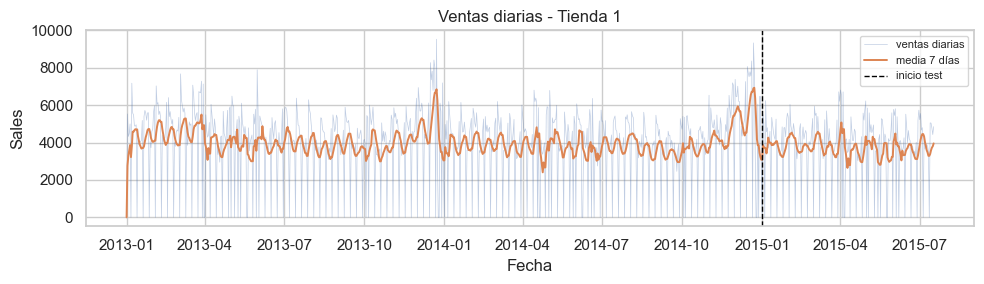

Tienda 1: 928 observaciones


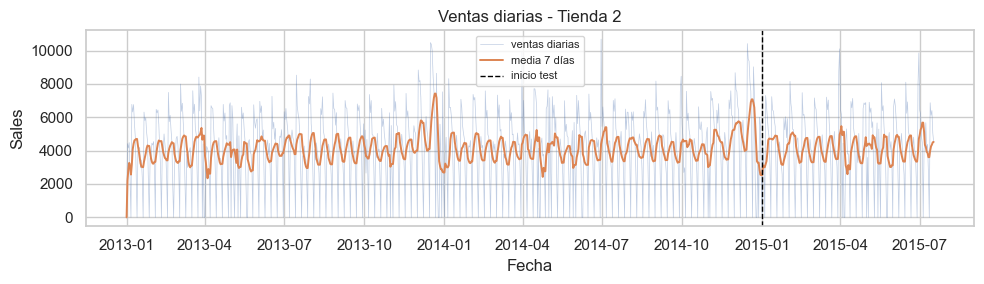

Tienda 2: 928 observaciones


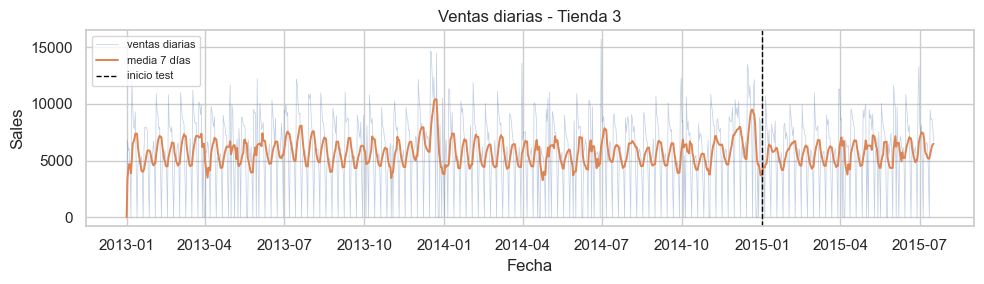

Tienda 3: 928 observaciones


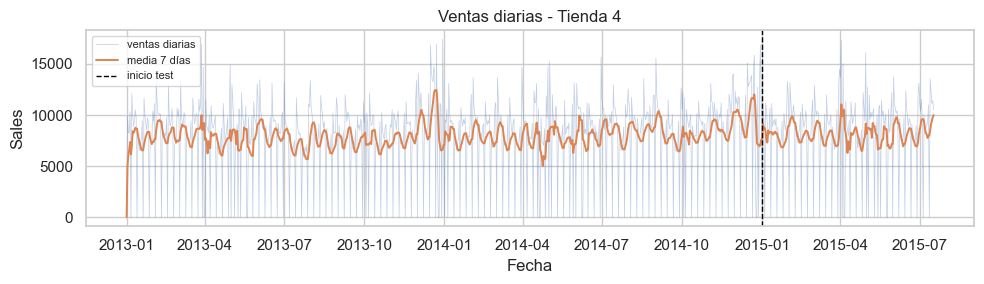

Tienda 4: 928 observaciones


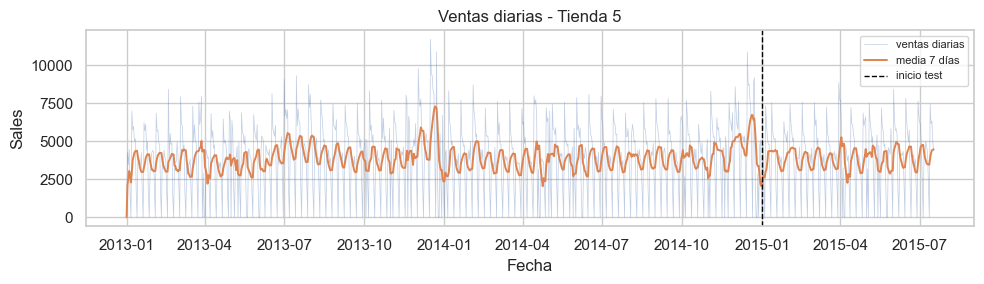

Tienda 5: 928 observaciones


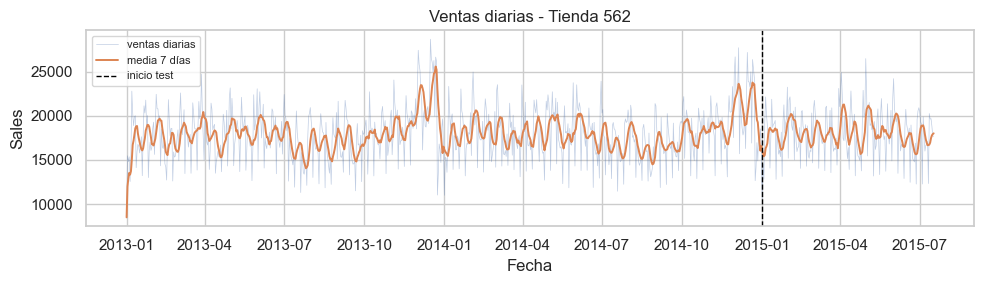

Tienda 562: 928 observaciones


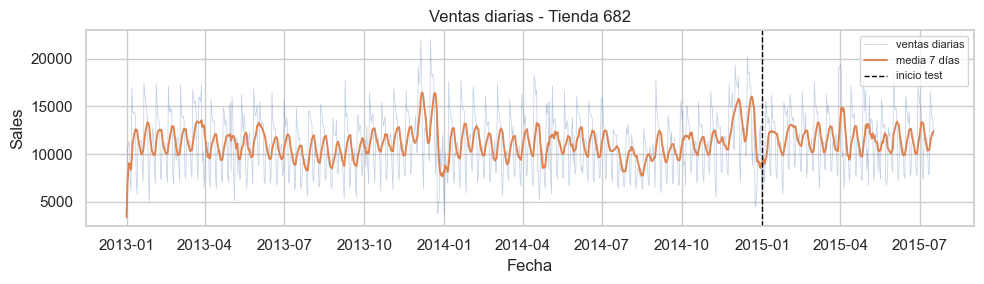

Tienda 682: 928 observaciones


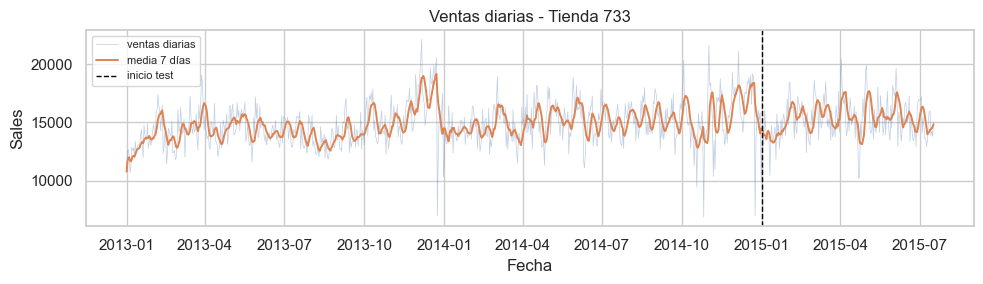

Tienda 733: 928 observaciones


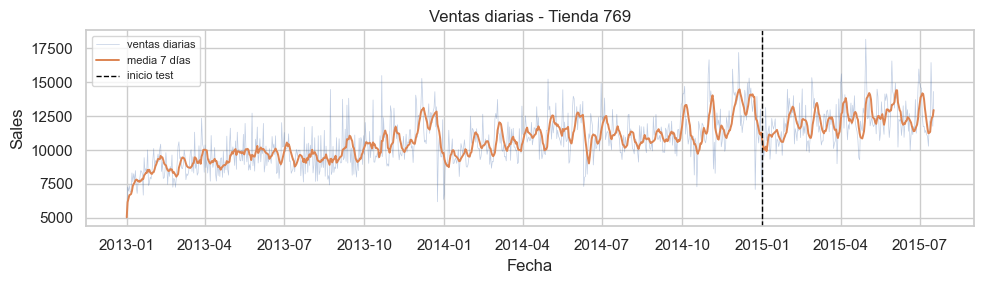

Tienda 769: 928 observaciones


In [6]:
for store_id in TIENDAS:
    aux = train_data.loc[train_data["Store"] == store_id].sort_values("Date").copy()
    aux["Sales_media_7d"] = aux["Sales"].rolling(7, min_periods=1).mean()

    plt.figure(figsize=(10, 3))
    plt.plot(aux["Date"], aux["Sales"], linewidth=0.5, alpha=0.35, label="ventas diarias")
    plt.plot(aux["Date"], aux["Sales_media_7d"], linewidth=1.4, label="media 7 días")
    plt.axvline(FECHA_CORTE, color="black", linestyle="--", linewidth=1, label="inicio test")
    plt.title(f"Ventas diarias - Tienda {store_id}")
    plt.xlabel("Fecha")
    plt.ylabel("Sales")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"Tienda {store_id}: {len(aux)} observaciones")

### Resumen estadístico por tienda

In [7]:
ventas_tiendas = train_data.loc[train_data["Store"].isin(TIENDAS)].copy()
ventas_tiendas["Month"] = ventas_tiendas["Date"].dt.month
ventas_tiendas["StateHoliday"] = ventas_tiendas["StateHoliday"].astype(str)

resumen_eda = (
    ventas_tiendas
    .groupby("Store")
    .agg(
        dias=("Sales", "size"),
        ventas_media=("Sales", "mean"),
        ventas_mediana=("Sales", "median"),
        ventas_std=("Sales", "std"),
        ventas_min=("Sales", "min"),
        ventas_max=("Sales", "max"),
        porcentaje_abierto=("Open", "mean"),
        porcentaje_promo=("Promo", "mean"),
        porcentaje_vacaciones_colegio=("SchoolHoliday", "mean"),
    )
    .reset_index()
)

resumen_eda.round(3)

,Store,dias,ventas_media,ventas_mediana,ventas_std,ventas_min,ventas_max,porcentaje_abierto,porcentaje_promo,porcentaje_vacaciones_colegio
0,1,928,3947.213,4373.5,2019.507,0,9528,0.829,0.383,0.203
1,2,928,4123.138,4395.5,2368.238,0,10682,0.832,0.383,0.169
2,3,928,5744.245,5902.5,3306.009,0,15689,0.827,0.383,0.172
3,4,928,8013.932,9048.5,4014.999,0,17412,0.832,0.383,0.176
4,5,928,3869.689,4186.0,2394.554,0,11692,0.827,0.383,0.175
5,562,928,17980.256,18041.0,2933.293,8498,28680,1.000,0.383,0.216
6,682,928,11217.641,11142.0,3262.246,3375,22052,1.000,0.383,0.176
7,733,928,14943.894,14803.5,1841.868,6838,22137,1.000,0.383,0.172
8,769,928,10817.038,10727.0,1859.183,5035,18177,1.000,0.383,0.172


### Diagramas de caja por tienda y variables categóricas

Se replican los gráficos exploratorios por tienda para revisar cómo cambian las ventas según calendario, apertura, promoción y vacaciones.

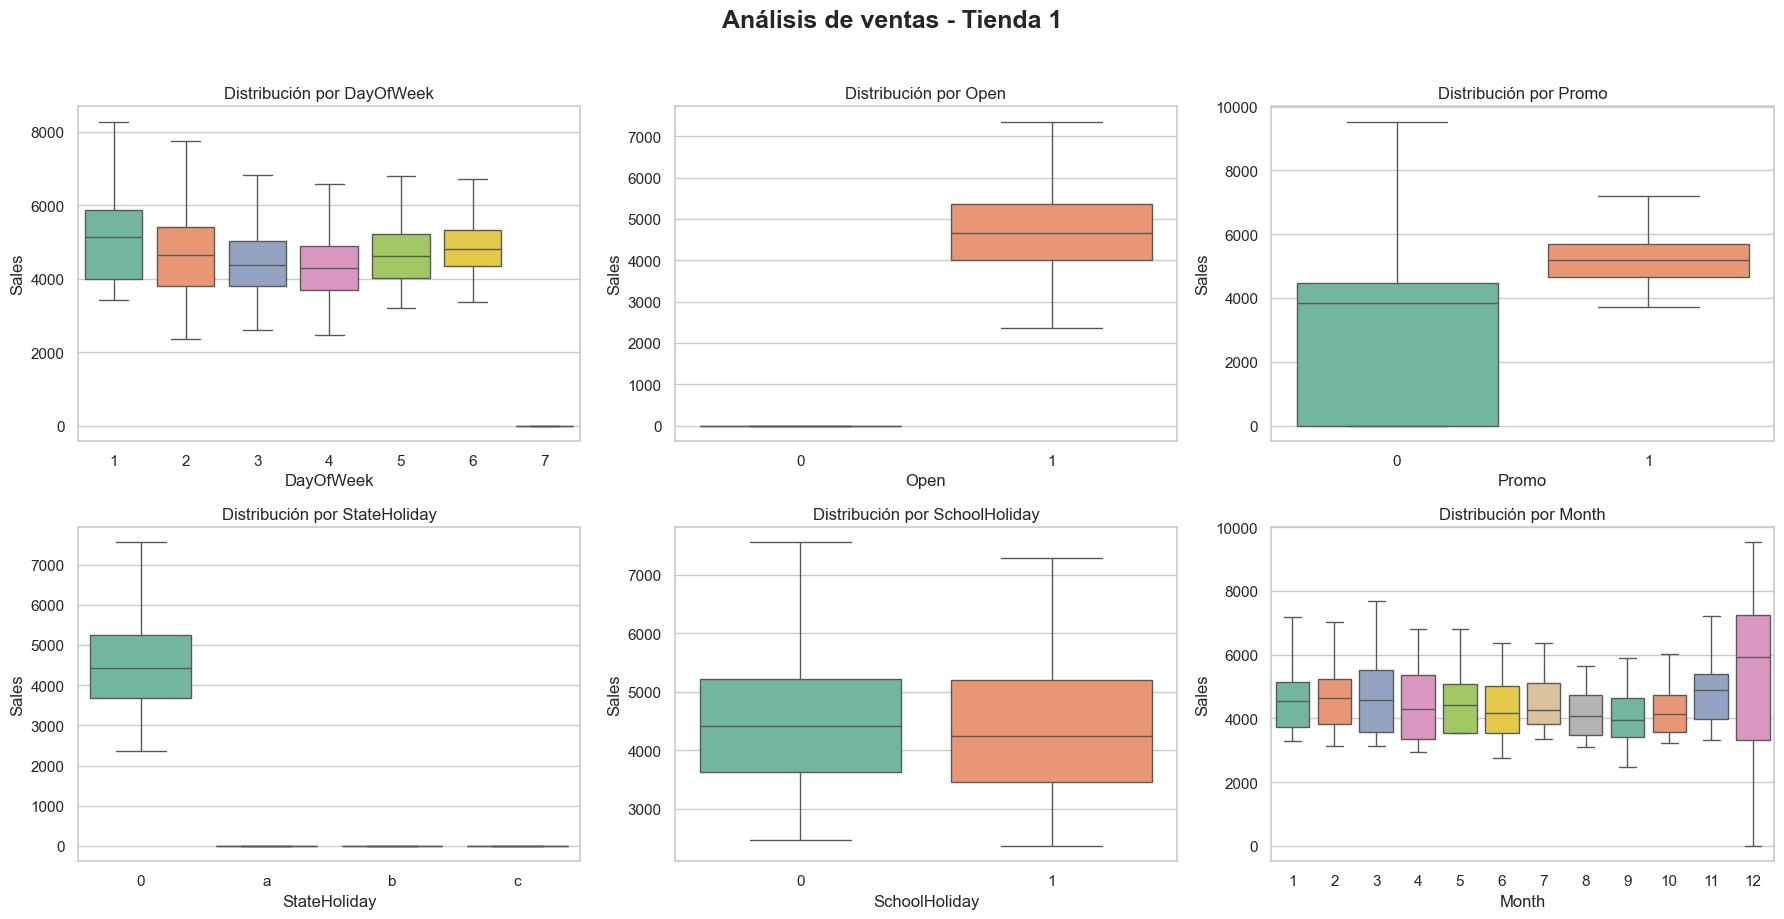

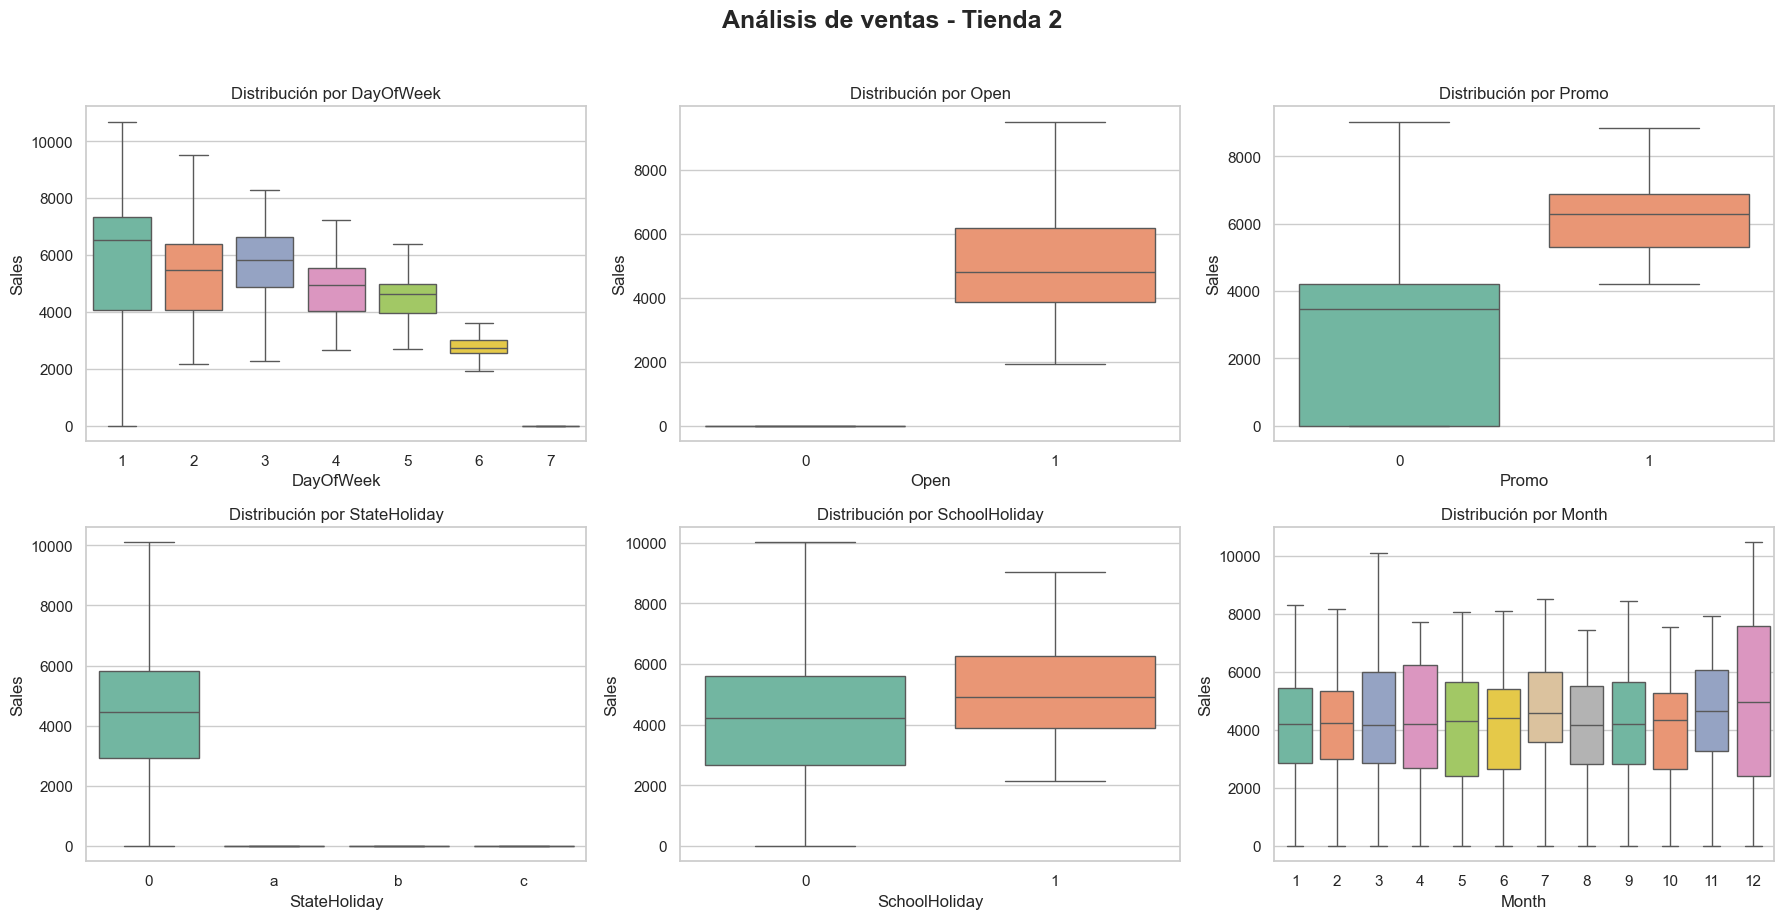

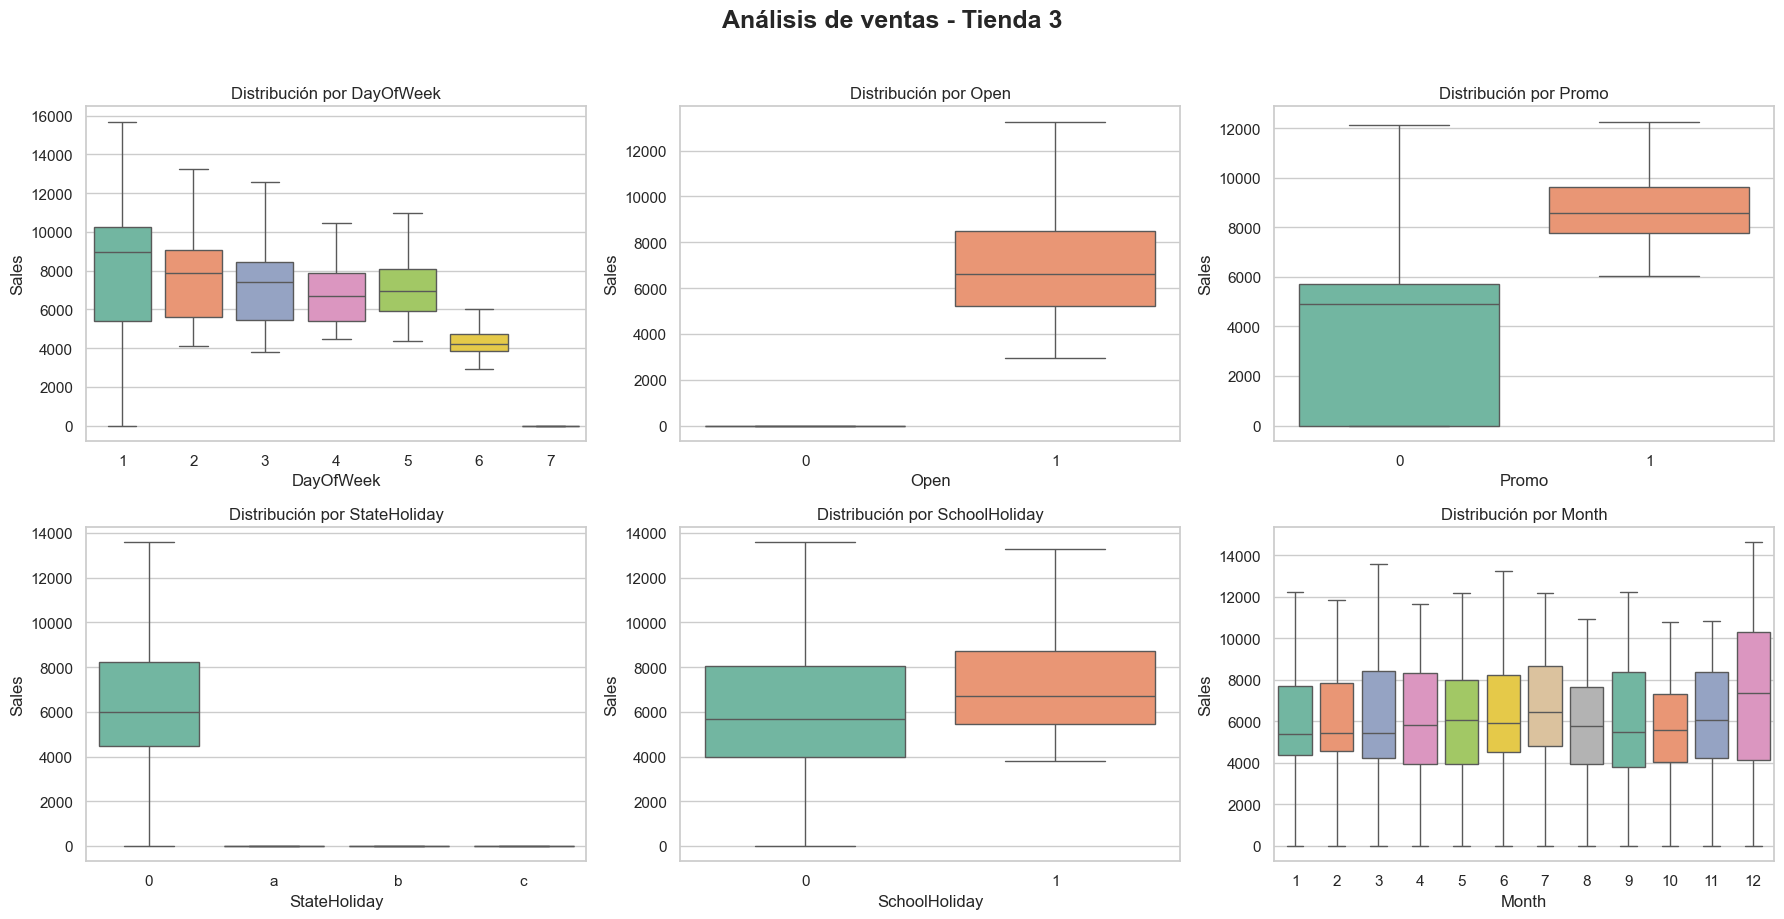

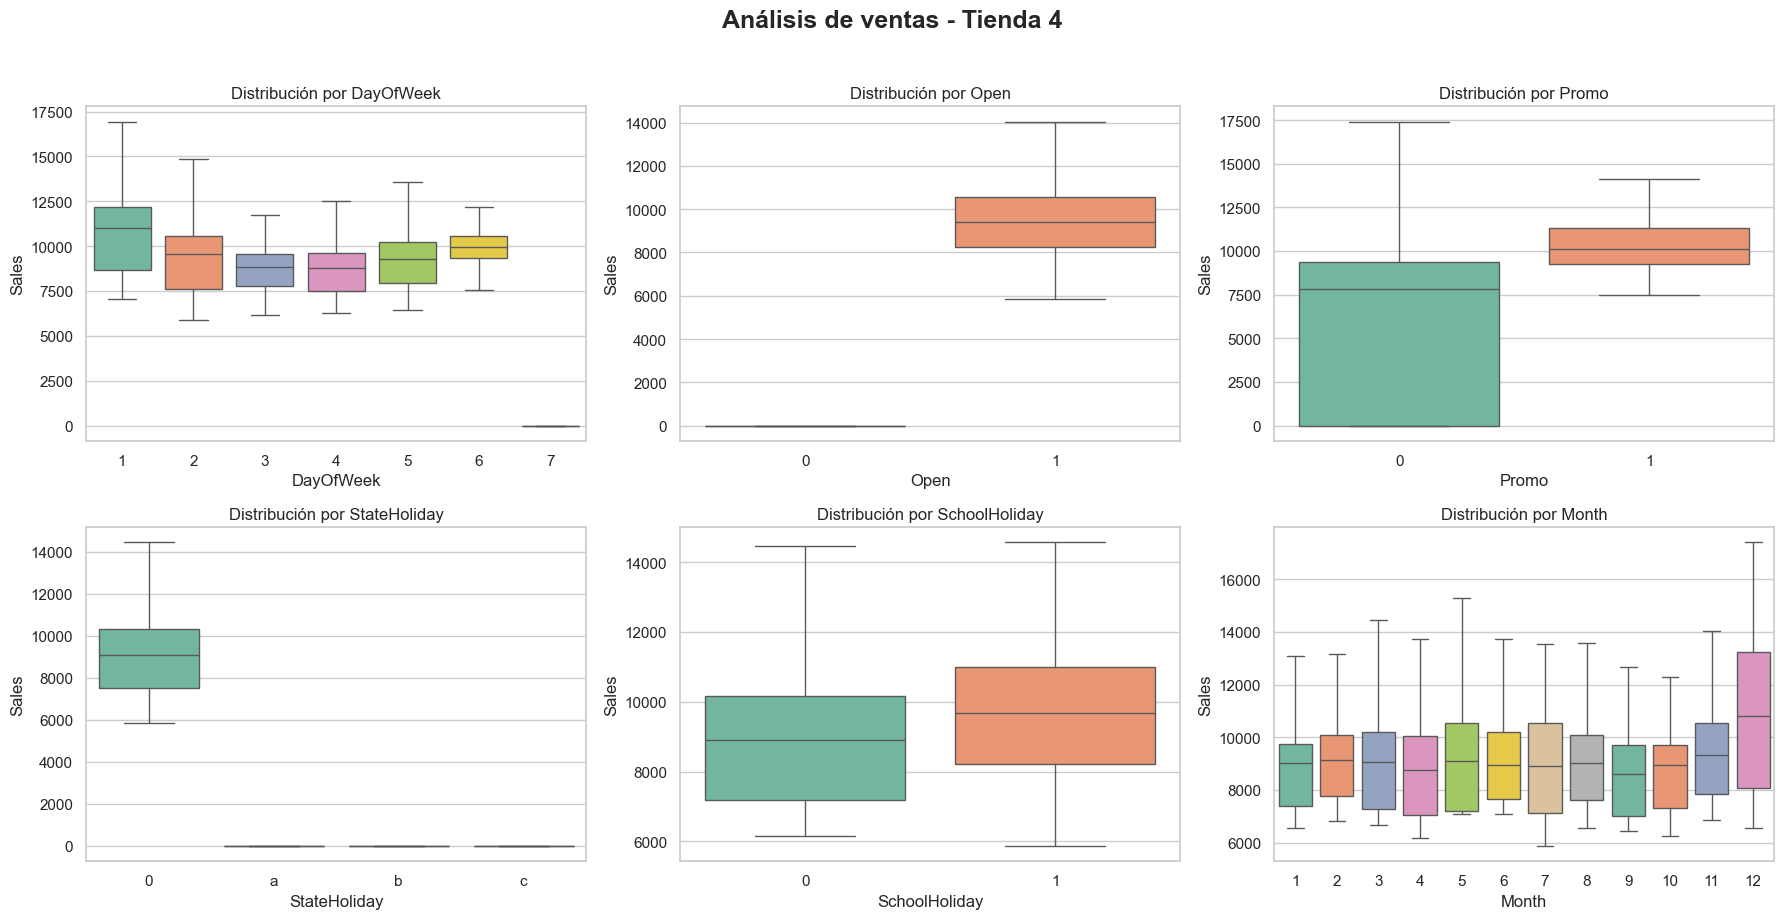

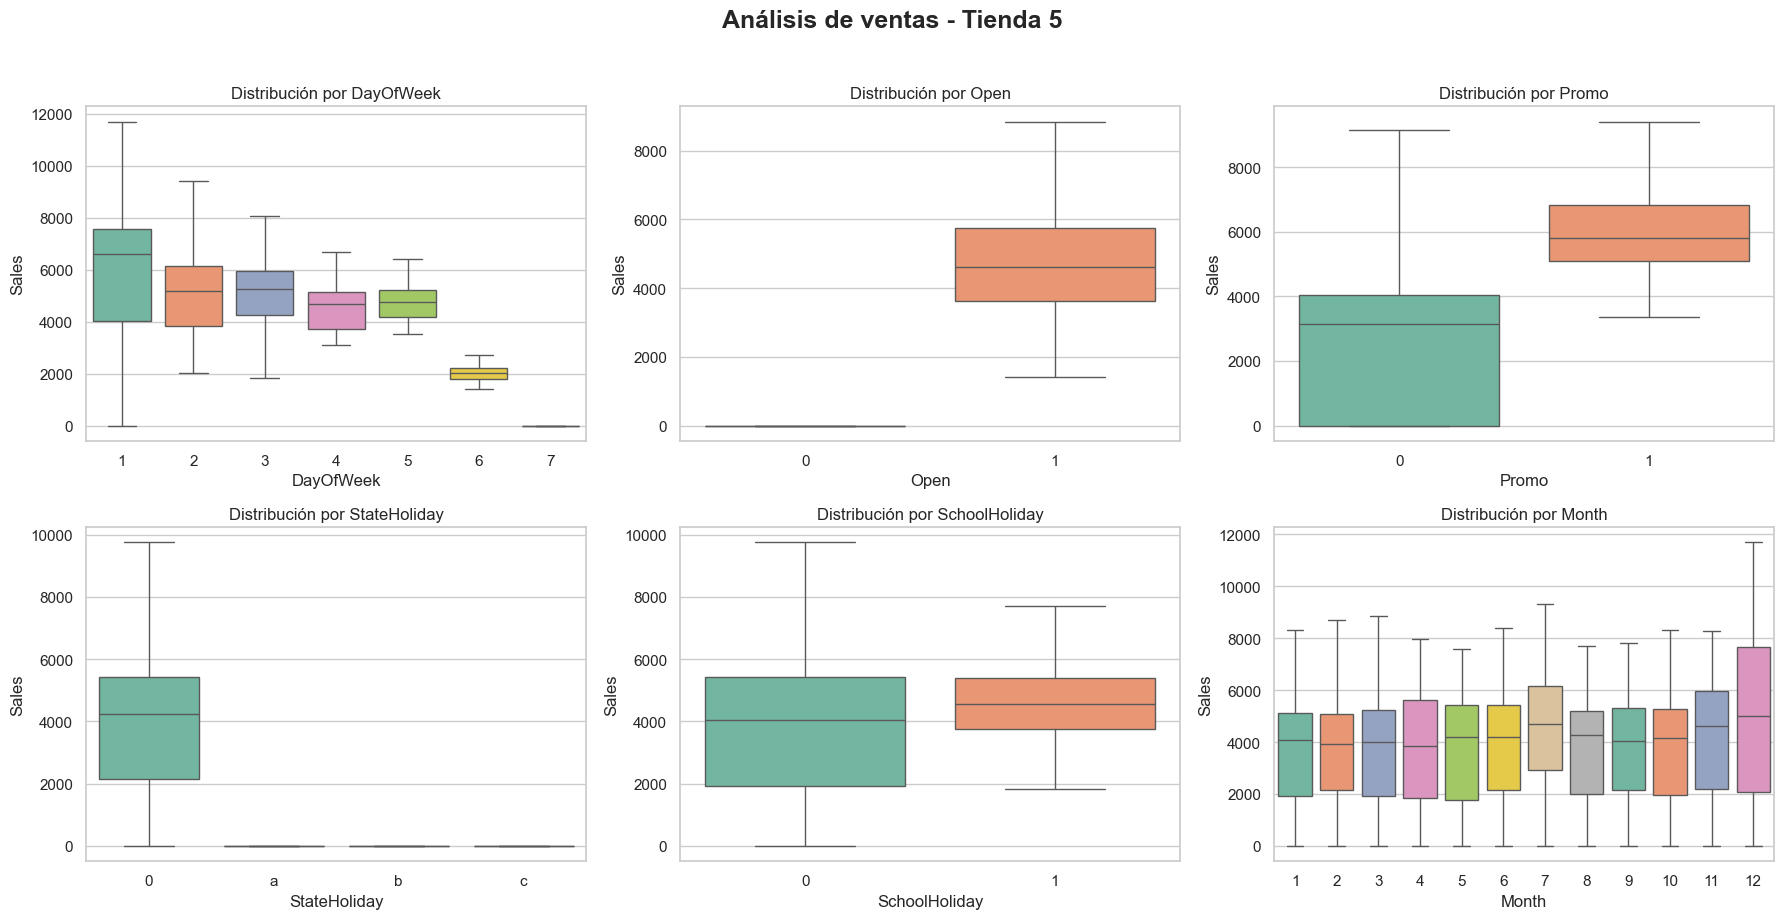

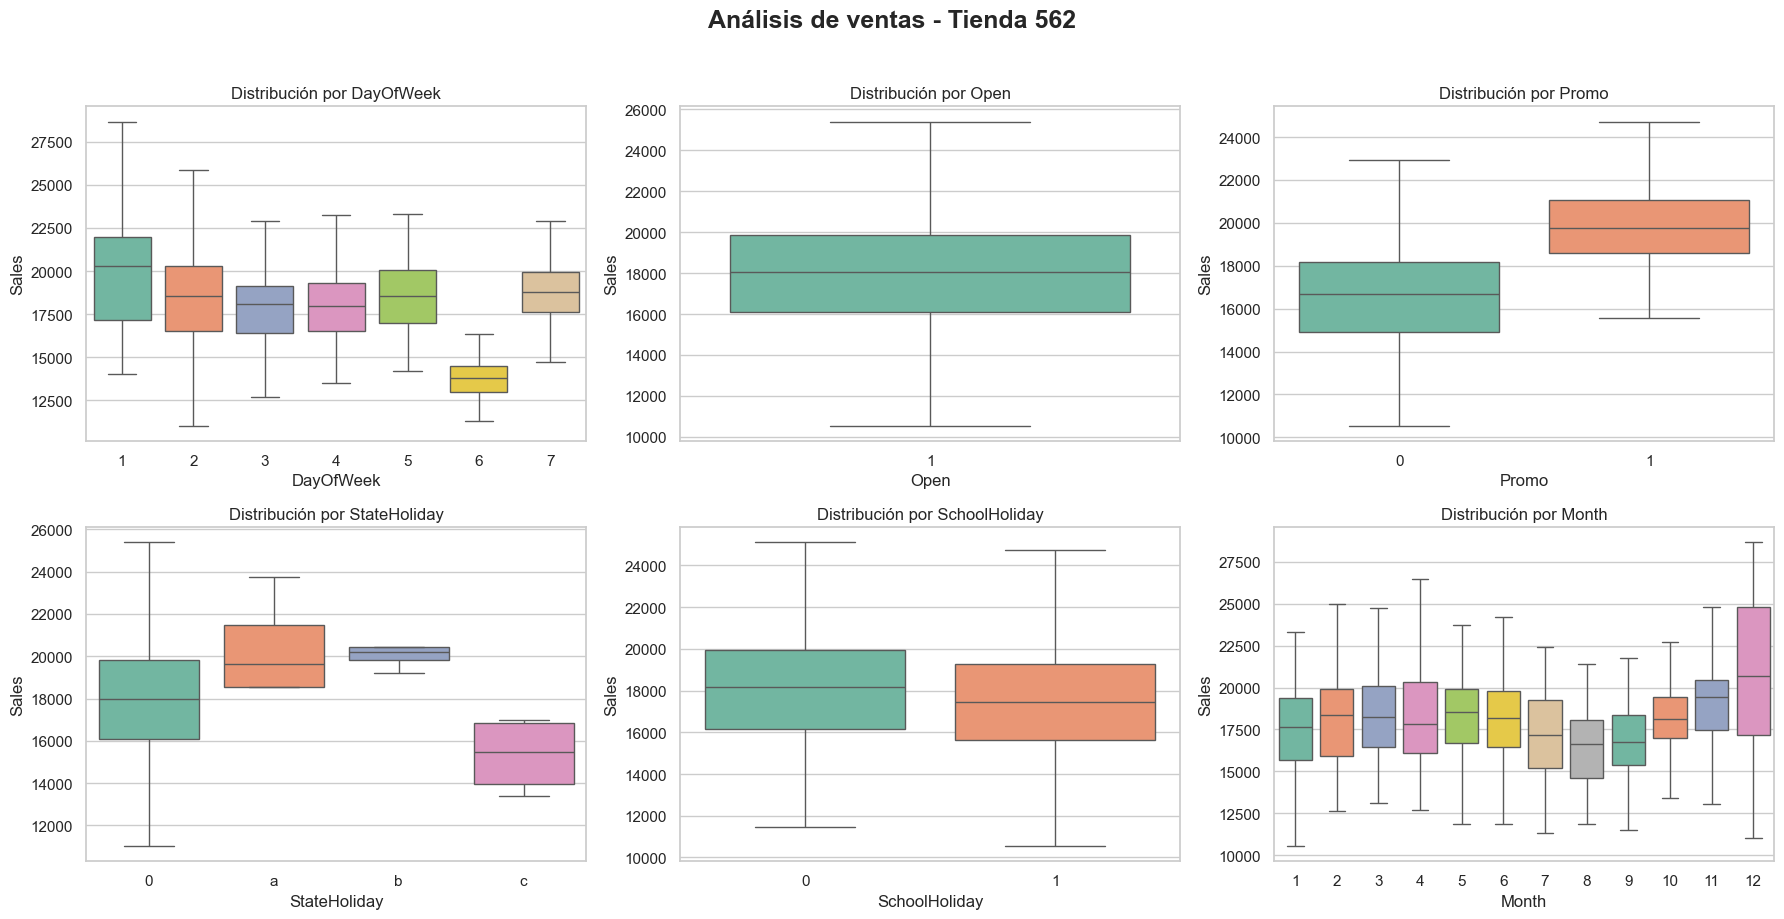

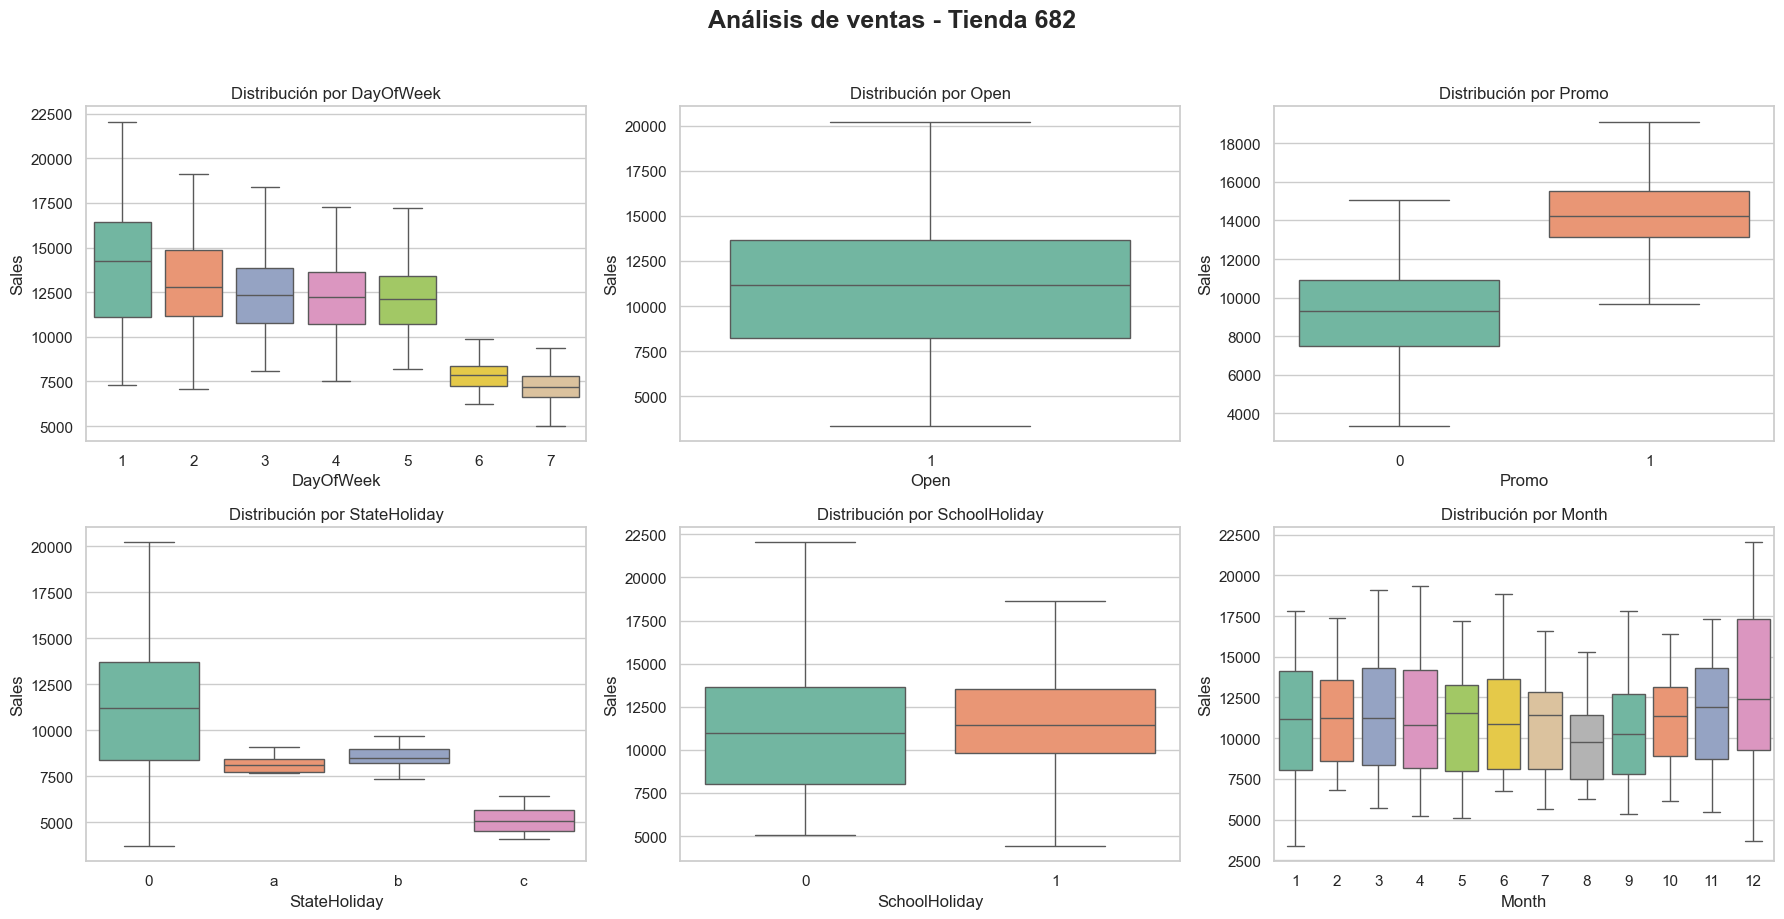

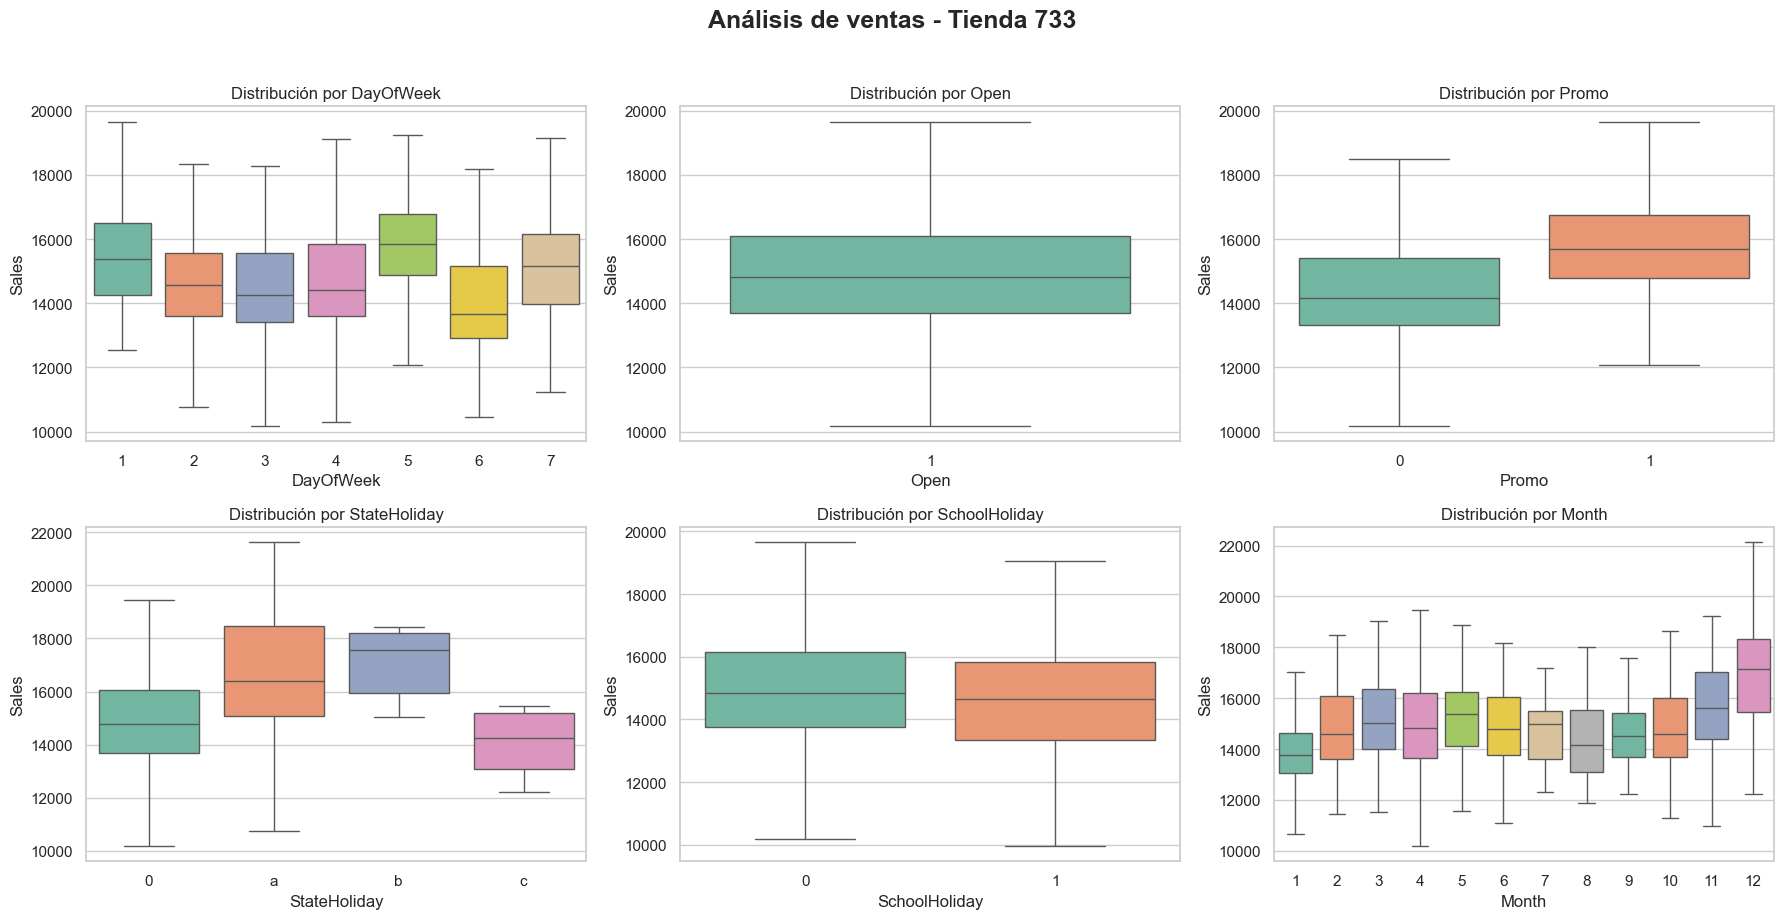

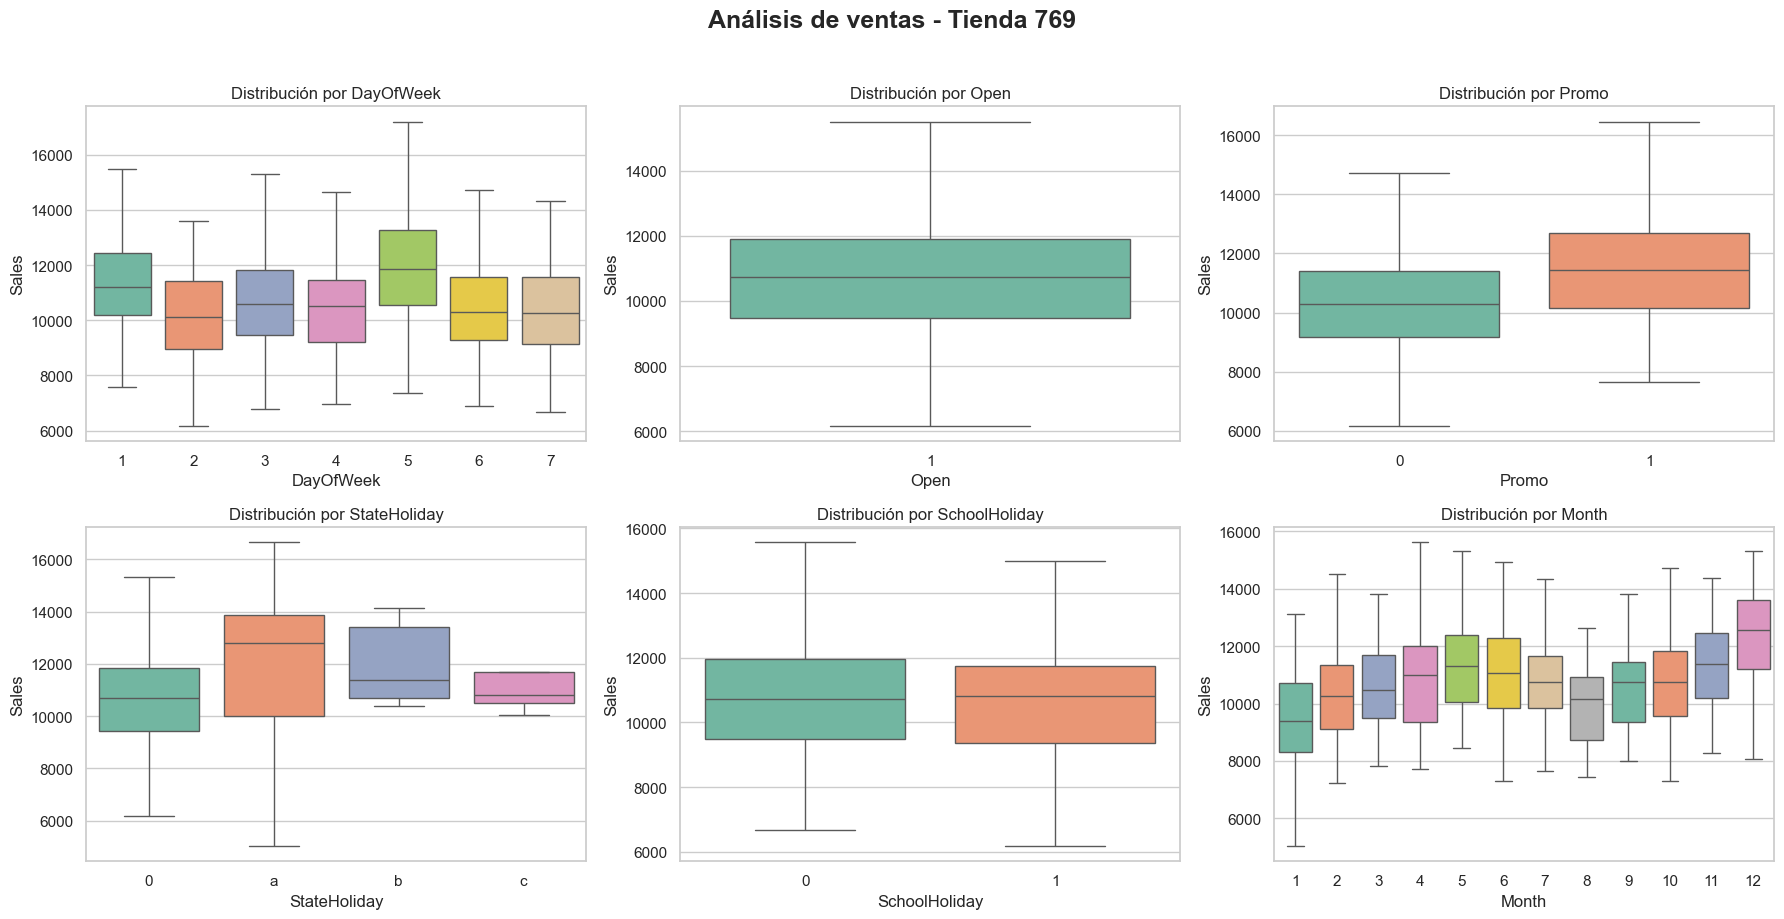

In [8]:
vars_categoricas = ["DayOfWeek", "Open", "Promo", "StateHoliday", "SchoolHoliday", "Month"]

for tienda in TIENDAS:
    df_tienda = ventas_tiendas.loc[ventas_tiendas["Store"] == tienda].copy()
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9))
    axes = axes.flatten()
    fig.suptitle(f"Análisis de ventas - Tienda {tienda}", fontsize=18, fontweight="bold", y=1.02)

    for i, var in enumerate(vars_categoricas):
        sns.boxplot(data=df_tienda, x=var, y="Sales", hue=var, ax=axes[i], palette="Set2", legend=False, showfliers=False)
        axes[i].set_title(f"Distribución por {var}")
        axes[i].set_xlabel(var)
        axes[i].set_ylabel("Sales")

    plt.tight_layout()
    plt.show()

## <font color="#CA3532"> **6. Preparación de datos por tienda**</font>

Se prepara una serie diaria independiente para cada tienda. El objetivo es aplicar el mismo criterio a todas antes de crear las ventanas del modelo.

Aspectos principales:

- ordenar las observaciones por fecha;
- codificar variables de calendario, apertura y promoción;
- crear rezagos de ventas a partir de la serie ya ordenada;
- conservar `Sales` como variable objetivo;
- excluir `Customers` como entrada.


In [9]:
MAPA_HOLIDAY = {"0": 0, "a": 1, "b": 2, "c": 3}

CAT_COLS = ["DayOfWeek", "StateHoliday", "Month"]
BIN_COLS = ["Open", "Promo", "SchoolHoliday"]
LAG_INFO = {
    "Sales_lag_1_day": 1,
    "Sales_lag_2_day": 2,
    "Sales_lag_1_week": 7,
    "Sales_lag_2_week": 14,
}
LAG_COLS = list(LAG_INFO.keys())
TREND_COLS = ["lin_idx", "sin_doy", "cos_doy"]
BASE_FEATURE_COLS = ["DayOfWeek", "Open", "Promo", "StateHoliday", "SchoolHoliday", "Month"]

registro_variables = pd.DataFrame([
    {"variable": "DayOfWeek", "tipo": "categórica", "tratamiento": "Embedding", "se_conoce_antes": "sí"},
    {"variable": "StateHoliday", "tipo": "categórica", "tratamiento": "Embedding", "se_conoce_antes": "sí"},
    {"variable": "Month", "tipo": "categórica", "tratamiento": "Embedding", "se_conoce_antes": "sí"},
    {"variable": "Open", "tipo": "binaria", "tratamiento": "entrada directa", "se_conoce_antes": "sí"},
    {"variable": "Promo", "tipo": "binaria", "tratamiento": "entrada directa", "se_conoce_antes": "sí"},
    {"variable": "SchoolHoliday", "tipo": "binaria", "tratamiento": "entrada directa", "se_conoce_antes": "sí"},
    {"variable": "Sales_lag_1_day", "tipo": "numérica histórica", "tratamiento": "StandardScaler", "se_conoce_antes": "solo pasado"},
    {"variable": "Sales_lag_2_day", "tipo": "numérica histórica", "tratamiento": "StandardScaler", "se_conoce_antes": "solo pasado"},
    {"variable": "Sales_lag_1_week", "tipo": "numérica histórica", "tratamiento": "StandardScaler", "se_conoce_antes": "solo pasado"},
    {"variable": "Sales_lag_2_week", "tipo": "numérica histórica", "tratamiento": "StandardScaler", "se_conoce_antes": "solo pasado"},
    {"variable": "lin_idx", "tipo": "numérica calendario", "tratamiento": "StandardScaler", "se_conoce_antes": "sí"},
    {"variable": "sin_doy", "tipo": "numérica calendario", "tratamiento": "StandardScaler", "se_conoce_antes": "sí"},
    {"variable": "cos_doy", "tipo": "numérica calendario", "tratamiento": "StandardScaler", "se_conoce_antes": "sí"},
])

registro_variables

,variable,tipo,tratamiento,se_conoce_antes
0,DayOfWeek,categórica,Embedding,sí
1,StateHoliday,categórica,Embedding,sí
2,Month,categórica,Embedding,sí
3,Open,binaria,entrada directa,sí
4,Promo,binaria,entrada directa,sí
5,SchoolHoliday,binaria,entrada directa,sí
6,Sales_lag_1_day,numérica histórica,StandardScaler,solo pasado
7,Sales_lag_2_day,numérica histórica,StandardScaler,solo pasado
8,Sales_lag_1_week,numérica histórica,StandardScaler,solo pasado
9,Sales_lag_2_week,numérica histórica,StandardScaler,solo pasado


In [10]:
def procesar_tienda(store_id, verbose=False):
    '''Devuelve los datos diarios de una tienda, ordenados y con variables básicas preparadas.'''
    df = train_data.loc[train_data["Store"] == store_id].copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").set_index("Date")

    rango = pd.date_range(df.index.min(), df.index.max(), freq="D")
    if not df.index.equals(rango):
        faltantes = rango.difference(df.index)
        raise ValueError(f"Tienda {store_id}: faltan fechas: {list(faltantes[:5])}")

    df["StateHoliday"] = df["StateHoliday"].astype(str).map(MAPA_HOLIDAY).astype("int32")
    df["DayOfWeek"] = df["DayOfWeek"].astype("int32")
    df["Month"] = df.index.month.astype("int32")
    df["Open"] = df["Open"].fillna(1).astype("int32")
    df["Promo"] = df["Promo"].astype("int32")
    df["SchoolHoliday"] = df["SchoolHoliday"].astype("int32")
    df["Sales"] = df["Sales"].astype("float32")
    df["lin_idx"] = np.arange(len(df), dtype="float32") / max(1, int((df.index < FECHA_CORTE).sum()))
    df["sin_doy"] = np.sin(2 * np.pi * df.index.dayofyear / 365.25).astype("float32")
    df["cos_doy"] = np.cos(2 * np.pi * df.index.dayofyear / 365.25).astype("float32")

    if verbose:
        print(
            f"Tienda {store_id}: {len(df)} días, "
            f"{df.index.min().date()} -> {df.index.max().date()}, "
            f"test={int((df.index >= FECHA_CORTE).sum())} días"
        )
    return df


def crear_lags(df):
    '''Añade ventas pasadas como variables explicativas.'''
    df = df.copy()
    for nombre_columna, lag in LAG_INFO.items():
        df[nombre_columna] = df["Sales"].shift(lag)
    return df.dropna(subset=LAG_COLS).copy()


_ = procesar_tienda(1, verbose=True).head()
_

Tienda 1: 928 días, 2013-01-01 -> 2015-07-17, test=198 días


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,Month,lin_idx,sin_doy,cos_doy
Date,,,,,,,,,,,,,
2013-01-01,1,2,0.0,0,0,0,1,1,690197,1,0.000000,0.017202,0.999852
2013-01-02,1,3,5530.0,668,1,0,0,1,988300,1,0.001370,0.034398,0.999408
2013-01-03,1,4,4327.0,578,1,0,0,1,919910,1,0.002740,0.051584,0.998669
2013-01-04,1,5,4486.0,619,1,0,0,1,662609,1,0.004110,0.068755,0.997634
2013-01-05,1,6,4997.0,635,1,0,0,1,1008092,1,0.005479,0.085906,0.996303


### Alineación temporal de entradas y objetivo

Se revisa que las ventanas de entrada y las ventas objetivo proceden de la misma serie ordenada por fecha. Así se evita entrenar el modelo con entradas y objetivos desalineados.

In [11]:
filas_orden = []
for tienda in TIENDAS:
    df = crear_lags(procesar_tienda(tienda))
    filas_orden.append({
        "tienda": tienda,
        "X_inicio": df.index.min().date(),
        "X_fin": df.index.max().date(),
        "y_inicio": df.index.min().date(),
        "y_fin": df.index.max().date(),
        "orden_cronologico": bool(df.index.is_monotonic_increasing),
        "filas": len(df),
    })

pd.DataFrame(filas_orden)

,tienda,X_inicio,X_fin,y_inicio,y_fin,orden_cronologico,filas
0,1,2013-01-15,2015-07-17,2013-01-15,2015-07-17,True,914
1,2,2013-01-15,2015-07-17,2013-01-15,2015-07-17,True,914
2,3,2013-01-15,2015-07-17,2013-01-15,2015-07-17,True,914
3,4,2013-01-15,2015-07-17,2013-01-15,2015-07-17,True,914
4,5,2013-01-15,2015-07-17,2013-01-15,2015-07-17,True,914
5,562,2013-01-15,2015-07-17,2013-01-15,2015-07-17,True,914
6,682,2013-01-15,2015-07-17,2013-01-15,2015-07-17,True,914
7,733,2013-01-15,2015-07-17,2013-01-15,2015-07-17,True,914
8,769,2013-01-15,2015-07-17,2013-01-15,2015-07-17,True,914


## <font color="#CA3532"> **7. Partición temporal de datos**</font>

Una vez construidas las ventanas, las observaciones se separan por fecha. La validación se toma del tramo inmediatamente anterior al test, de forma que la evaluación respeta el orden temporal de la serie.

La partición queda así:

- **train:** fechas anteriores al tramo de validación;
- **validación:** últimos 90 días antes de 2015;
- **test:** desde el 1 de enero de 2015 hasta el final disponible.


### **Justificación de la preparación de datos**

La preparación de datos se ha diseñado con tres objetivos: conservar el orden temporal, evitar fuga de información y adaptar las variables al tipo de entrada que espera la red neuronal.

Los rezagos de ventas (`Sales_lag_1_day`, `Sales_lag_2_day`, `Sales_lag_1_week`, `Sales_lag_2_week`) aportan información reciente y patrón semanal sin utilizar ventas futuras. Los escaladores de variables numéricas y de `Sales` se ajustan únicamente con el tramo de entrenamiento, no con validación ni test.

`Customers` se excluye porque se conoce al final del día, mientras que el objetivo de la práctica es predecir las ventas antes de observar el resultado real. Las variables de calendario (`DayOfWeek`, `Month`, `StateHoliday`) y de funcionamiento de la tienda (`Open`, `Promo`, `SchoolHoliday`) sí se consideran conocidas antes de hacer la predicción.


In [12]:
def ajustar_scaler_target(df, mask_train, kind=TARGET_TRANSFORM):
    valores_train = df.loc[mask_train, ["Sales"]].astype("float32")
    if kind == "log1p_zscore":
        valores_train = np.log1p(valores_train)
    return StandardScaler().fit(valores_train)


def transformar_target_valores(sales, scaler_y, kind=TARGET_TRANSFORM):
    valores = np.asarray(sales, dtype="float32").reshape(-1, 1)
    if kind == "log1p_zscore":
        valores = np.log1p(valores)
    valores = pd.DataFrame(valores, columns=["Sales"])
    return scaler_y.transform(valores).ravel().astype("float32")


def destransformar_target(datos, y_scaled):
    valores = pd.DataFrame(np.asarray(y_scaled).reshape(-1, 1), columns=["Sales"])
    valores = datos["scaler_y"].inverse_transform(valores).ravel()
    if datos["target_transform"] == "log1p_zscore":
        valores = np.expm1(valores)
    return valores


def enventanar_matriz(df_scaled, feature_cols, target_col, data_window):
    X, y, fechas, reales, abiertos = [], [], [], [], []
    valores_x = df_scaled[feature_cols].to_numpy(dtype="float32")
    valores_y = df_scaled[target_col].to_numpy(dtype="float32")
    valores_reales = df_scaled["Sales"].to_numpy(dtype="float32")
    valores_open = df_scaled["Open"].to_numpy(dtype="int32")
    fechas_idx = df_scaled.index.to_numpy()

    for i in range(data_window - 1, len(df_scaled)):
        X.append(valores_x[i - data_window + 1:i + 1])
        y.append(valores_y[i])
        fechas.append(fechas_idx[i])
        reales.append(valores_reales[i])
        abiertos.append(valores_open[i])

    return (
        np.asarray(X, dtype="float32"),
        np.asarray(y, dtype="float32"),
        pd.to_datetime(fechas),
        np.asarray(reales, dtype="float32"),
        np.asarray(abiertos, dtype="int32"),
    )


def separar_entradas(X):
    '''Adapta la matriz de ventanas al formato de entradas del modelo funcional.'''
    return {
        "DayOfWeek": X[:, :, 0].astype("int32"),
        "StateHoliday": X[:, :, 3].astype("int32"),
        "Month": X[:, :, 5].astype("int32"),
        "binarias": X[:, :, [1, 2, 4]].astype("float32"),
        "numericas": X[:, :, 6:].astype("float32"),
    }


def preparar_tienda(
    store_id,
    data_window=DATA_WINDOW,
    n_val=N_VAL,
    target_transform=TARGET_TRANSFORM,
    use_trend=False,
):
    df_base = procesar_tienda(store_id)
    df = crear_lags(df_base)
    num_cols = LAG_COLS + (TREND_COLS if use_trend else [])
    feature_cols = BASE_FEATURE_COLS + num_cols

    fecha_val = FECHA_CORTE - pd.Timedelta(days=n_val)
    mask_train = df.index < fecha_val

    scaler_x = StandardScaler().fit(df.loc[mask_train, num_cols])
    scaler_y = ajustar_scaler_target(df, mask_train, target_transform)

    df_scaled = df.copy()
    df_scaled[num_cols] = scaler_x.transform(df[num_cols])
    df_scaled["Sales_scaled"] = transformar_target_valores(df["Sales"], scaler_y, target_transform)

    X_all, y_all, fechas, reales, abiertos = enventanar_matriz(df_scaled, feature_cols, "Sales_scaled", data_window)

    mask_tr = fechas < fecha_val
    mask_va = (fechas >= fecha_val) & (fechas < FECHA_CORTE)
    mask_te = fechas >= FECHA_CORTE
    masks = {"tr": mask_tr, "va": mask_va, "te": mask_te}

    return {
        "store_id": store_id,
        "df_base": df_base,
        "df": df,
        "fecha_val": fecha_val,
        "scaler_x": scaler_x,
        "scaler_y": scaler_y,
        "target_transform": target_transform,
        "use_trend": use_trend,
        "num_cols": num_cols,
        "feature_cols": feature_cols,
        "Xs": {k: separar_entradas(X_all[m]) for k, m in masks.items()},
        "ys": {k: y_all[m].astype("float32") for k, m in masks.items()},
        "reales": {k: reales[m].astype("float32") for k, m in masks.items()},
        "fechas": {k: fechas[m] for k, m in masks.items()},
        "open": {k: abiertos[m].astype("int32") for k, m in masks.items()},
    }

In [13]:
datos_tiendas = {tienda: preparar_tienda(tienda) for tienda in TIENDAS}

filas = []
for tienda, datos in datos_tiendas.items():
    filas.append({
        "tienda": tienda,
        "train": len(datos["ys"]["tr"]),
        "validación": len(datos["ys"]["va"]),
        "test": len(datos["ys"]["te"]),
        "inicio_train": datos["fechas"]["tr"][0].date(),
        "fin_train": datos["fechas"]["tr"][-1].date(),
        "inicio_validación": datos["fechas"]["va"][0].date(),
        "fin_validación": datos["fechas"]["va"][-1].date(),
        "inicio_test": datos["fechas"]["te"][0].date(),
        "fin_test": datos["fechas"]["te"][-1].date(),
    })

resumen_particiones = pd.DataFrame(filas)
resumen_particiones

,tienda,train,validación,test,inicio_train,fin_train,inicio_validación,fin_validación,inicio_test,fin_test
0,1,622,90,198,2013-01-19,2014-10-02,2014-10-03,2014-12-31,2015-01-01,2015-07-17
1,2,622,90,198,2013-01-19,2014-10-02,2014-10-03,2014-12-31,2015-01-01,2015-07-17
2,3,622,90,198,2013-01-19,2014-10-02,2014-10-03,2014-12-31,2015-01-01,2015-07-17
3,4,622,90,198,2013-01-19,2014-10-02,2014-10-03,2014-12-31,2015-01-01,2015-07-17
4,5,622,90,198,2013-01-19,2014-10-02,2014-10-03,2014-12-31,2015-01-01,2015-07-17
5,562,622,90,198,2013-01-19,2014-10-02,2014-10-03,2014-12-31,2015-01-01,2015-07-17
6,682,622,90,198,2013-01-19,2014-10-02,2014-10-03,2014-12-31,2015-01-01,2015-07-17
7,733,622,90,198,2013-01-19,2014-10-02,2014-10-03,2014-12-31,2015-01-01,2015-07-17
8,769,622,90,198,2013-01-19,2014-10-02,2014-10-03,2014-12-31,2015-01-01,2015-07-17


## <font color="#CA3532"> **8. Modelos de referencia**</font>

Antes de entrenar redes neuronales se calculan dos modelos de referencia sencillos: ventas de ayer y ventas de la semana anterior.

In [14]:
def calcular_r2(y_real, y_pred):
    return R2_score(np.asarray(y_real).ravel(), np.asarray(y_pred).ravel())


def calcular_r2_abiertos(y_real, y_pred, abiertos):
    abiertos = np.asarray(abiertos).astype(bool)
    return calcular_r2(np.asarray(y_real)[abiertos], np.asarray(y_pred)[abiertos])


def evaluar_baselines(datos_tiendas):
    filas = []
    for tienda, datos in datos_tiendas.items():
        df = datos["df"]
        fechas_test = pd.DatetimeIndex(datos["fechas"]["te"])
        y_test = datos["reales"]["te"]
        abiertos_test = datos["open"]["te"]

        pred_lag_1 = df.loc[fechas_test, "Sales_lag_1_day"].to_numpy()
        pred_lag_7 = df.loc[fechas_test, "Sales_lag_1_week"].to_numpy()

        filas.append({
            "tienda": tienda,
            "R2_baseline_ayer": calcular_r2(y_test, pred_lag_1),
            "R2_baseline_semana": calcular_r2(y_test, pred_lag_7),
            "R2_baseline_ayer_abiertos": calcular_r2_abiertos(y_test, pred_lag_1, abiertos_test),
            "R2_baseline_semana_abiertos": calcular_r2_abiertos(y_test, pred_lag_7, abiertos_test),
        })
    return pd.DataFrame(filas)

baseline_resultados = evaluar_baselines(datos_tiendas)
baseline_resultados.round(4)

,tienda,R2_baseline_ayer,R2_baseline_semana,R2_baseline_ayer_abiertos,R2_baseline_semana_abiertos
0,1,-1.3675,0.1666,-7.0040,-3.0946
1,2,-0.5539,0.0064,-2.3609,-1.2636
2,3,-0.7557,-0.0070,-3.1687,-1.6124
3,4,-1.4718,0.2075,-6.6919,-2.7651
4,5,-0.6072,0.0582,-2.3171,-0.8516
5,562,-0.5568,-0.4446,-0.5568,-0.4446
6,682,-0.2670,-0.2685,-0.2670,-0.2685
7,733,-0.0809,-1.0019,-0.0809,-1.0019
8,769,-0.0413,-1.0341,-0.0413,-1.0341


## <font color="#CA3532"> **9. Modelo neuronal con entradas heterogéneas**</font>

El modelo se construye con **Keras Functional API** porque hay varias ramas de entrada. Las variables categóricas pasan por embeddings, las binarias entran directamente y los rezagos de ventas entran como variables numéricas estandarizadas. Después se unen con `Concatenate`.

### **Justificación de la arquitectura**

Se utiliza Keras Functional API porque las entradas no tienen la misma naturaleza. Las variables categóricas, binarias y numéricas se tratan por separado antes de combinarlas en una representación común.

Las variables categóricas se transforman con capas `Embedding`, lo que permite aprender una representación de cada categoría sin imponer una relación ordinal artificial. Las variables binarias entran directamente, y las variables numéricas históricas se estandarizan para facilitar el entrenamiento.

Sobre la representación combinada se prueban bloques recurrentes y convolucionales. Las LSTM y GRU son adecuadas para capturar dependencias dentro de la ventana temporal; las Conv1D permiten detectar patrones locales; y el dropout se utiliza como regularización.


### **Arquitectura del modelo**

La arquitectura utilizada se resume así:

- entrada categórica `DayOfWeek` → `Embedding`;
- entrada categórica `StateHoliday` → `Embedding`;
- entrada categórica `Month` → `Embedding`;
- entrada binaria (`Open`, `Promo`, `SchoolHoliday`) → entrada directa;
- entrada numérica histórica (`Sales_lag_*` y, en algunas configuraciones, tendencia/estacionalidad) → entrada estandarizada;
- unión de ramas con `Concatenate`;
- bloque principal del modelo: `LSTM`, `GRU`, `BiLSTM`, `Conv1D`, `Conv1D-GRU`, `Conv1D-LSTM` o `Inception1D`;
- capa densa intermedia;
- salida final de una neurona para predecir `Sales_scaled`.


In [15]:
def crear_optimizador(nombre, lr):
    if nombre.lower() == "rmsprop":
        return optimizers.RMSprop(learning_rate=lr)
    return optimizers.Adam(learning_rate=lr)


def construir_modelo(config, n_numericas, data_window=DATA_WINDOW):
    input_day = Input(shape=(data_window,), name="DayOfWeek")
    input_holiday = Input(shape=(data_window,), name="StateHoliday")
    input_month = Input(shape=(data_window,), name="Month")
    input_bin = Input(shape=(data_window, len(BIN_COLS)), name="binarias")
    input_num = Input(shape=(data_window, n_numericas), name="numericas")

    emb_day = layers.Embedding(input_dim=8, output_dim=config["dim_embedding"], name="embedding_DayOfWeek")(input_day)
    emb_holiday = layers.Embedding(input_dim=4, output_dim=config["dim_embedding"], name="embedding_StateHoliday")(input_holiday)
    emb_month = layers.Embedding(input_dim=13, output_dim=config["dim_embedding"], name="embedding_Month")(input_month)

    x = layers.Concatenate(name="concatenar_entradas")([emb_day, emb_holiday, emb_month, input_bin, input_num])
    tipo = config["tipo"].upper()
    units = config["units"]
    dropout = config["dropout"]

    if tipo in ["LSTM", "GRU"]:
        capa = layers.GRU if tipo == "GRU" else layers.LSTM
        for i in range(config["layers_recurrentes"]):
            return_sequences = i < config["layers_recurrentes"] - 1
            x = capa(units, activation="tanh", return_sequences=return_sequences, name=f"{tipo}_{i+1}")(x)
            if dropout > 0:
                x = layers.Dropout(dropout, name=f"dropout_{i+1}")(x)
    elif tipo == "BILSTM":
        x = layers.Bidirectional(layers.LSTM(units, activation="tanh"), name="BiLSTM")(x)
        if dropout > 0:
            x = layers.Dropout(dropout, name="dropout_bilstm")(x)
    elif tipo == "CONV1D":
        for i in range(max(1, config["layers_recurrentes"])):
            x = layers.Conv1D(units, kernel_size=3, padding="same", activation="relu", name=f"conv1d_{i+1}")(x)
        x = layers.GlobalMaxPooling1D(name="global_max_pooling")(x)
        if dropout > 0:
            x = layers.Dropout(dropout, name="dropout_conv")(x)
    elif tipo in ["CONV1D-GRU", "CONV1D-LSTM"]:
        x = layers.Conv1D(units, kernel_size=3, padding="same", activation="relu", name="conv1d_1")(x)
        x = layers.Conv1D(units, kernel_size=3, padding="same", activation="relu", name="conv1d_2")(x)
        capa = layers.GRU if tipo.endswith("GRU") else layers.LSTM
        x = capa(units, activation="tanh", name=tipo.replace("-", "_"))(x)
        if dropout > 0:
            x = layers.Dropout(dropout, name="dropout_conv_recurrente")(x)
    elif tipo == "INCEPTION1D":
        ramas = [
            layers.Conv1D(units, kernel_size=k, padding="same", activation="relu", name=f"conv_k{k}")(x)
            for k in [3, 5, 7]
        ]
        x = layers.Concatenate(name="concat_inception")(ramas)
        x = layers.GlobalMaxPooling1D(name="global_max_pooling_inception")(x)
        if dropout > 0:
            x = layers.Dropout(dropout, name="dropout_inception")(x)
    else:
        raise ValueError(f"Arquitectura no reconocida: {tipo}")

    x = layers.Dense(max(4, units // 2), activation="relu", name="densa_intermedia")(x)
    output = layers.Dense(1, name="Sales_scaled")(x)

    model = Model(
        inputs=[input_day, input_holiday, input_month, input_bin, input_num],
        outputs=output,
        name=f"modelo_{tipo.lower()}_heterogeneo",
    )
    model.compile(loss="mean_squared_error", optimizer=crear_optimizador(config["optimizer_name"], config["lr"]))
    return model



## <font color="#CA3532"> **10. Entrenamiento y rejilla de modelos**</font>

Se prueban varias arquitecturas y cada configuración se repite con dos semillas. La configuración ganadora de cada tienda se elige por R² de validación, nunca por test.

### **Diseño experimental**

La comparación no se limita a un único modelo. Se parte de modelos de referencia sencillos y después se prueban 15 configuraciones neuronales: LSTM base, LSTM más profundas, LSTM con dropout, transformación `log1p_zscore`, `gate_open`, tendencia/estacionalidad, GRU con distintos ritmos de aprendizaje, BiLSTM, Conv1D, Conv1D-GRU, Conv1D-LSTM e Inception1D.

Cada configuración se entrena con dos semillas para reducir la dependencia de una inicialización concreta. La selección de la arquitectura ganadora se hace por R² de validación temporal. El test queda reservado para medir el rendimiento final, no para decidir el modelo.

También se entrenan modelos individualizados por tienda. Esta decisión aumenta el número de entrenamientos, pero es coherente con el problema: las tiendas tienen escalas de venta, patrones de cierre, promociones y estacionalidad diferentes. Un único modelo global podría mezclar comportamientos muy distintos si no se incorporasen mecanismos adicionales para identificar cada tienda.


In [16]:
def cfg(nombre, **kw):
    base = {
        "nombre": nombre,
        "tipo": "LSTM",
        "units": 16,
        "layers_recurrentes": 1,
        "dim_embedding": 2,
        "dropout": 0.00,
        "optimizer_name": "RMSprop",
        "lr": 1e-3,
        "target_transform": "zscore",
        "use_trend": False,
        "gate_open": False,
    }
    base.update(kw)
    return base


CONFIG_MODELOS = [
    cfg("Baseline LSTM-16 RMSprop"),
    cfg("LSTM-32 x2 dropout", units=32, layers_recurrentes=2, dim_embedding=4, dropout=0.20, optimizer_name="Adam"),
    cfg("LSTM-32 dropout", units=32, dim_embedding=4, dropout=0.25, optimizer_name="Adam", lr=5e-4),
    cfg("Target log1p LSTM-16", target_transform="log1p_zscore"),
    cfg("Gating Open LSTM-16", gate_open=True),
    cfg("Tendencia y estacionalidad LSTM-16", use_trend=True),
    cfg("GRU-16 Adam", tipo="GRU", dropout=0.10, optimizer_name="Adam"),
    cfg("GRU-32 Adam lr=1e-2", tipo="GRU", units=32, dim_embedding=4, dropout=0.10, optimizer_name="Adam", lr=1e-2),
    cfg("GRU-32 Adam lr=1e-3", tipo="GRU", units=32, dim_embedding=4, dropout=0.10, optimizer_name="Adam", lr=1e-3),
    cfg("GRU-32 Adam lr=5e-4", tipo="GRU", units=32, dim_embedding=4, dropout=0.20, optimizer_name="Adam", lr=5e-4),
    cfg("BiLSTM-16", tipo="BiLSTM", dim_embedding=4, dropout=0.15, optimizer_name="Adam"),
    cfg("Conv1D-32", tipo="Conv1D", units=32, layers_recurrentes=2, dim_embedding=4, dropout=0.10, optimizer_name="Adam"),
    cfg("Conv1D-GRU-32", tipo="Conv1D-GRU", units=32, dim_embedding=4, dropout=0.15, optimizer_name="Adam"),
    cfg("Conv1D-LSTM-32", tipo="Conv1D-LSTM", units=32, dim_embedding=4, dropout=0.15, optimizer_name="Adam"),
    cfg("Inception1D-24", tipo="Inception1D", units=24, dim_embedding=4, dropout=0.10, optimizer_name="Adam"),
]

print(f"Configuraciones: {len(CONFIG_MODELOS)}")
print(f"Semillas por configuración: {N_SEEDS}")
print(f"Entrenamientos previstos: {len(TIENDAS) * len(CONFIG_MODELOS) * N_SEEDS}")

Configuraciones: 15
Semillas por configuración: 2
Entrenamientos previstos: 270


In [17]:
def predecir_1_paso(model, datos, split, gate_open=False):
    pred_scaled = model.predict(datos["Xs"][split], verbose=0).ravel()
    pred = destransformar_target(datos, pred_scaled)
    if gate_open:
        pred = np.where(datos["open"][split] == 0, 0.0, pred)
    return np.clip(pred, 0, None)


def predecir_test_autorregresivo(model, datos, gate_open=False):
    df_base = datos["df_base"]
    scaler_x = datos["scaler_x"]
    fechas_test = pd.DatetimeIndex(datos["fechas"]["te"])

    historico = df_base.loc[df_base.index < FECHA_CORTE, "Sales"].astype(float).to_dict()
    predicciones = []

    for fecha in fechas_test:
        fechas_ventana = pd.date_range(fecha - pd.Timedelta(days=DATA_WINDOW - 1), fecha, freq="D")

        input_day = df_base.loc[fechas_ventana, "DayOfWeek"].to_numpy(dtype="int32").reshape(1, DATA_WINDOW)
        input_holiday = df_base.loc[fechas_ventana, "StateHoliday"].to_numpy(dtype="int32").reshape(1, DATA_WINDOW)
        input_month = df_base.loc[fechas_ventana, "Month"].to_numpy(dtype="int32").reshape(1, DATA_WINDOW)
        input_bin = df_base.loc[fechas_ventana, BIN_COLS].to_numpy(dtype="float32").reshape(1, DATA_WINDOW, len(BIN_COLS))

        filas_num = []
        for f in fechas_ventana:
            fila = [
                historico[f - pd.Timedelta(days=1)],
                historico[f - pd.Timedelta(days=2)],
                historico[f - pd.Timedelta(days=7)],
                historico[f - pd.Timedelta(days=14)],
            ]
            if datos["use_trend"]:
                fila.extend(df_base.loc[f, TREND_COLS].to_list())
            filas_num.append(fila)

        df_num = pd.DataFrame(filas_num, columns=datos["num_cols"])
        input_num = scaler_x.transform(df_num).reshape(1, DATA_WINDOW, len(datos["num_cols"])).astype("float32")

        pred_scaled = model(
            {
                "DayOfWeek": input_day,
                "StateHoliday": input_holiday,
                "Month": input_month,
                "binarias": input_bin,
                "numericas": input_num,
            },
            training=False,
        ).numpy()
        pred = float(destransformar_target(datos, pred_scaled)[0])

        if gate_open and int(df_base.loc[fecha, "Open"]) == 0:
            pred = 0.0

        pred = max(0.0, pred)
        historico[fecha] = pred
        predicciones.append(pred)

    return np.asarray(predicciones, dtype="float32")


def evaluar_modelo_rapido(model, datos, config):
    gate_open = config.get("gate_open", False)
    pred_train = predecir_1_paso(model, datos, "tr", gate_open=gate_open)
    pred_val = predecir_1_paso(model, datos, "va", gate_open=gate_open)
    pred_test = predecir_1_paso(model, datos, "te", gate_open=gate_open)

    return {
        "R2_train": calcular_r2(datos["reales"]["tr"], pred_train),
        "R2_val": calcular_r2(datos["reales"]["va"], pred_val),
        "R2_test_1_paso": calcular_r2(datos["reales"]["te"], pred_test),
        "R2_test_1_paso_abiertos": calcular_r2_abiertos(datos["reales"]["te"], pred_test, datos["open"]["te"]),
        "pred_test_1_paso": pred_test,
    }


def evaluar_modelo_final(model, datos, config):
    metricas = evaluar_modelo_rapido(model, datos, config)
    pred_auto = predecir_test_autorregresivo(model, datos, gate_open=config.get("gate_open", False))
    metricas["R2_test_autorregresivo"] = calcular_r2(datos["reales"]["te"], pred_auto)
    metricas["R2_test_autorregresivo_abiertos"] = calcular_r2_abiertos(datos["reales"]["te"], pred_auto, datos["open"]["te"])
    metricas["pred_test_autorregresivo"] = pred_auto
    return metricas

In [18]:
def entrenar_configuracion(tienda, datos, config):
    resultados_seed = []
    mejor = None

    for seed in SEEDS[:N_SEEDS]:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seed + int(tienda))

        model = construir_modelo(config, n_numericas=len(datos["num_cols"]))
        early_stopping = callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
        )

        history = model.fit(
            datos["Xs"]["tr"],
            datos["ys"]["tr"],
            validation_data=(datos["Xs"]["va"], datos["ys"]["va"]),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stopping],
            verbose=0,
        )

        metricas = evaluar_modelo_rapido(model, datos, config)
        resultados_seed.append({
            "semilla": seed,
            "epocas": len(history.history["loss"]),
            "R2_train": metricas["R2_train"],
            "R2_val": metricas["R2_val"],
            "R2_test_1_paso": metricas["R2_test_1_paso"],
            "R2_test_1_paso_abiertos": metricas["R2_test_1_paso_abiertos"],
        })

        if mejor is None or metricas["R2_val"] > mejor["metricas"]["R2_val"]:
            mejor = {"model": model, "history": history, "metricas": metricas, "semilla": seed}

    df_seed = pd.DataFrame(resultados_seed)
    resultado = {
        "tienda": tienda,
        "modelo": config["nombre"],
        "tipo": config["tipo"],
        "target_transform": config["target_transform"],
        "use_trend": config["use_trend"],
        "gate_open": config["gate_open"],
        "semilla_mejor": mejor["semilla"],
        "epocas": int(round(df_seed["epocas"].mean())),
        "R2_train": df_seed["R2_train"].mean(),
        "R2_val": df_seed["R2_val"].mean(),
        "R2_val_std": df_seed["R2_val"].std(ddof=0),
        "R2_test_1_paso": df_seed["R2_test_1_paso"].mean(),
        "R2_test_1_paso_abiertos": df_seed["R2_test_1_paso_abiertos"].mean(),
    }

    return resultado, mejor["model"], mejor["history"]

In [19]:
resultados = []
modelos_ganadores = {}
historias_ganadoras = {}
predicciones_ganadoras = {}
cache_datos = {(tienda, TARGET_TRANSFORM, False): datos_tiendas[tienda] for tienda in TIENDAS}


def obtener_datos_tienda(tienda, config):
    key = (tienda, config["target_transform"], config["use_trend"])
    if key not in cache_datos:
        cache_datos[key] = preparar_tienda(
            tienda,
            target_transform=config["target_transform"],
            use_trend=config["use_trend"],
        )
    return cache_datos[key]

for tienda in TIENDAS:
    mejor_tienda = None
    print(f"\n===== Tienda {tienda} =====")

    for config in CONFIG_MODELOS:
        datos = obtener_datos_tienda(tienda, config)
        resultado, model, history = entrenar_configuracion(tienda, datos, config)
        resultados.append(resultado)
        print(
            f"{config['nombre']:<28} | "
            f"R2_val={resultado['R2_val']:.4f} ± {resultado['R2_val_std']:.3f} | "
            f"R2_test_1_paso={resultado['R2_test_1_paso']:.4f}"
        )

        if mejor_tienda is None or resultado["R2_val"] > mejor_tienda["resultado"]["R2_val"]:
            mejor_tienda = {"resultado": resultado, "model": model, "history": history}

    config_ganadora = next(c for c in CONFIG_MODELOS if c["nombre"] == mejor_tienda["resultado"]["modelo"])
    datos_ganadores = obtener_datos_tienda(tienda, config_ganadora)
    metricas_finales = evaluar_modelo_final(mejor_tienda["model"], datos_ganadores, config_ganadora)
    mejor_tienda["resultado"].update({
        "R2_train": metricas_finales["R2_train"],
        "R2_val": metricas_finales["R2_val"],
        "R2_test_1_paso": metricas_finales["R2_test_1_paso"],
        "R2_test_1_paso_abiertos": metricas_finales["R2_test_1_paso_abiertos"],
        "R2_test_autorregresivo": metricas_finales["R2_test_autorregresivo"],
        "R2_test_autorregresivo_abiertos": metricas_finales["R2_test_autorregresivo_abiertos"],
    })

    modelos_ganadores[tienda] = mejor_tienda["model"]
    historias_ganadoras[tienda] = mejor_tienda["history"]
    predicciones_ganadoras[tienda] = metricas_finales

    mejor_tienda["model"].save(MODELOS_DIR / f"modelo_tienda_{tienda}.keras")
    print(
        f"-> Ganadora tienda {tienda}: {mejor_tienda['resultado']['modelo']} | "
        f"R2_test_auto={mejor_tienda['resultado']['R2_test_autorregresivo']:.4f}"
    )

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos


===== Tienda 1 =====


Baseline LSTM-16 RMSprop     | R2_val=0.8909 ± 0.002 | R2_test_1_paso=0.9403


LSTM-32 x2 dropout           | R2_val=0.8824 ± 0.009 | R2_test_1_paso=0.9213


LSTM-32 dropout              | R2_val=0.8883 ± 0.002 | R2_test_1_paso=0.9341


Target log1p LSTM-16         | R2_val=0.8861 ± 0.009 | R2_test_1_paso=0.9298


...

Conv1D-GRU-32                | R2_val=0.3395 ± 0.065 | R2_test_1_paso=0.2697


Conv1D-LSTM-32               | R2_val=0.3327 ± 0.054 | R2_test_1_paso=0.1806


Inception1D-24               | R2_val=0.3385 ± 0.065 | R2_test_1_paso=0.2044


-> Ganadora tienda 769: GRU-32 Adam lr=1e-3 | R2_test_auto=-0.0184


,tienda,modelo,tipo,target_transform,use_trend,gate_open,semilla_mejor,epocas,R2_train,R2_val,R2_val_std,R2_test_1_paso,R2_test_1_paso_abiertos,R2_test_autorregresivo,R2_test_autorregresivo_abiertos
0,1,Baseline LSTM-16 RMSprop,LSTM,zscore,False,False,7,85,0.954839,0.890897,0.002085,0.940313,0.628473,NaN,NaN
1,1,LSTM-32 x2 dropout,LSTM,zscore,False,False,13,76,0.949807,0.882421,0.009391,0.921275,0.549484,NaN,NaN
2,1,LSTM-32 dropout,LSTM,zscore,False,False,7,118,0.953998,0.888336,0.002336,0.934146,0.600364,NaN,NaN
3,1,Target log1p LSTM-16,LSTM,log1p_zscore,False,False,7,128,0.950207,0.886112,0.009208,0.929812,0.549801,NaN,NaN
4,1,Gating Open LSTM-16,LSTM,zscore,False,True,7,85,0.961228,0.900581,0.001929,0.939371,0.611114,0.922017,0.4998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,769,BiLSTM-16,BiLSTM,zscore,False,False,7,52,0.625652,0.257269,0.033529,0.172454,0.172454,NaN,NaN
131,769,Conv1D-32,Conv1D,zscore,False,False,7,44,0.741218,0.292330,0.048997,0.213332,0.213332,NaN,NaN
132,769,Conv1D-GRU-32,Conv1D-GRU,zscore,False,False,7,40,0.691997,0.339491,0.064784,0.269665,0.269665,NaN,NaN
133,769,Conv1D-LSTM-32,Conv1D-LSTM,zscore,False,False,7,62,0.812896,0.332701,0.054147,0.180642,0.180642,NaN,NaN


## <font color="#CA3532"> **11. Resultados por tienda**</font>

La tabla muestra el modelo ganador de cada tienda, elegido por validación temporal.

### **Evaluación autorregresiva de los modelos ganadores**

El cálculo autorregresivo se reserva para el modelo ganador de cada tienda. Por eso, en la tabla completa de configuraciones, las columnas autorregresivas de los modelos descartados pueden quedar vacías.

La comparación entre arquitecturas se hace con validación temporal y test a un paso. La evaluación autorregresiva se informa después para los modelos finalmente seleccionados.


In [20]:
tabla_ganadores = (
    resultados_modelos
    .sort_values(["tienda", "R2_val"], ascending=[True, False])
    .groupby("tienda", as_index=False)
    .head(1)
    .sort_values("tienda")
    .reset_index(drop=True)
)

tabla_final = tabla_ganadores.merge(baseline_resultados, on="tienda", how="left")
columnas = [
    "tienda", "modelo", "tipo", "target_transform", "use_trend", "gate_open",
    "semilla_mejor", "epocas",
    "R2_baseline_ayer", "R2_baseline_semana",
    "R2_baseline_ayer_abiertos", "R2_baseline_semana_abiertos",
    "R2_train", "R2_val", "R2_val_std",
    "R2_test_1_paso", "R2_test_1_paso_abiertos",
    "R2_test_autorregresivo", "R2_test_autorregresivo_abiertos",
]
tabla_final = tabla_final[columnas]
tabla_final.round(4)

,tienda,modelo,tipo,target_transform,use_trend,gate_open,semilla_mejor,epocas,R2_baseline_ayer,R2_baseline_semana,R2_baseline_ayer_abiertos,R2_baseline_semana_abiertos,R2_train,R2_val,R2_val_std,R2_test_1_paso,R2_test_1_paso_abiertos,R2_test_autorregresivo,R2_test_autorregresivo_abiertos
0,1,Gating Open LSTM-16,LSTM,zscore,False,True,7,85,-1.3675,0.1666,-7.0040,-3.0946,0.9612,0.9006,0.0019,0.9394,0.6111,0.9220,0.4998
1,2,Gating Open LSTM-16,LSTM,zscore,False,True,7,85,-0.5539,0.0064,-2.3609,-1.2636,0.9544,0.9220,0.0018,0.9395,0.8318,0.9383,0.8283
2,3,LSTM-32 dropout,LSTM,zscore,False,False,7,120,-0.7557,-0.0070,-3.1687,-1.6124,0.9419,0.9034,0.0047,0.9492,0.8417,0.9489,0.8406
3,4,LSTM-32 dropout,LSTM,zscore,False,False,7,107,-1.4718,0.2075,-6.6919,-2.7651,0.9381,0.9109,0.0052,0.9247,0.5809,0.9005,0.4576
4,5,Gating Open LSTM-16,LSTM,zscore,False,True,7,100,-0.6072,0.0582,-2.3171,-0.8516,0.9655,0.9052,0.0071,0.9493,0.8774,0.9179,0.8016
5,562,LSTM-32 dropout,LSTM,zscore,False,False,7,124,-0.5568,-0.4446,-0.5568,-0.4446,0.8468,0.7724,0.0141,0.7472,0.7472,0.6622,0.6622
6,682,GRU-16 Adam,GRU,zscore,False,False,7,89,-0.2670,-0.2685,-0.2670,-0.2685,0.9351,0.8501,0.0041,0.9149,0.9149,0.8787,0.8787
7,733,LSTM-32 x2 dropout,LSTM,zscore,False,False,7,68,-0.0809,-1.0019,-0.0809,-1.0019,0.7435,0.5581,0.0185,0.4473,0.4473,0.2669,0.2669
8,769,GRU-32 Adam lr=1e-3,GRU,zscore,False,False,7,76,-0.0413,-1.0341,-0.0413,-1.0341,0.7083,0.4537,0.0437,0.3153,0.3153,-0.0184,-0.0184


In [21]:
resumen_global = pd.DataFrame({
    "métrica": [
        "R2_test_1_paso_medio",
        "R2_test_1_paso_abiertos_medio",
        "R2_test_autorregresivo_medio",
        "R2_test_autorregresivo_abiertos_medio",
        "R2_baseline_ayer_medio",
        "R2_baseline_semana_medio",
    ],
    "valor": [
        tabla_final["R2_test_1_paso"].mean(),
        tabla_final["R2_test_1_paso_abiertos"].mean(),
        tabla_final["R2_test_autorregresivo"].mean(),
        tabla_final["R2_test_autorregresivo_abiertos"].mean(),
        tabla_final["R2_baseline_ayer"].mean(),
        tabla_final["R2_baseline_semana"].mean(),
    ]
})
resumen_global.round(4)

,métrica,valor
0,R2_test_1_paso_medio,0.7919
1,R2_test_1_paso_abiertos_medio,0.6853
2,R2_test_autorregresivo_medio,0.7130
3,R2_test_autorregresivo_abiertos_medio,0.5797
4,R2_baseline_ayer_medio,-0.6336
5,R2_baseline_semana_medio,-0.2575


### **Resumen de resultados**

Los modelos neuronales ganadores superan claramente a los modelos de referencia sencillos. La media de R² en test a un paso es aproximadamente **0.792**, mientras que la media autorregresiva es aproximadamente **0.713**. En cambio, los modelos de referencia basados en ayer y en la semana anterior tienen medias negativas, lo que indica que no son suficientes para capturar la dinámica de ventas de estas tiendas.

La diferencia entre test a un paso y test autorregresivo es esperable. En la predicción a un paso se utilizan rezagos reales disponibles en la serie; en la predicción autorregresiva, las ventas predichas se reutilizan para construir los rezagos de días posteriores.

También se informa el R² en días abiertos. Esta lectura es útil porque los días cerrados introducen muchos ceros y pueden mejorar artificialmente algunas métricas. Evaluar solo días abiertos permite comprobar si el modelo aprende la magnitud real de las ventas cuando la tienda opera.


### Comparación agregada de arquitecturas

In [22]:
tabla_arquitecturas = (
    resultados_modelos
    .groupby(["modelo", "tipo"], as_index=False)
    .agg(
        R2_val_medio=("R2_val", "mean"),
        R2_val_std_medio=("R2_val_std", "mean"),
        R2_test_1_paso_medio=("R2_test_1_paso", "mean"),
        R2_test_1_paso_abiertos_medio=("R2_test_1_paso_abiertos", "mean"),
        epocas_medias=("epocas", "mean"),
    )
    .sort_values("R2_val_medio", ascending=False)
    .reset_index(drop=True)
)

tabla_arquitecturas.round(4)

,modelo,tipo,R2_val_medio,R2_val_std_medio,R2_test_1_paso_medio,R2_test_1_paso_abiertos_medio,epocas_medias
0,LSTM-32 dropout,LSTM,0.7744,0.0090,0.7836,0.6764,112.5556
1,GRU-32 Adam lr=1e-3,GRU,0.7710,0.0086,0.8011,0.7021,63.3333
2,GRU-32 Adam lr=5e-4,GRU,0.7644,0.0090,0.7902,0.6881,105.1111
3,Gating Open LSTM-16,LSTM,0.7595,0.0097,0.7658,0.6578,86.3333
4,BiLSTM-16,BiLSTM,0.7588,0.0094,0.7665,0.6610,81.3333
5,GRU-16 Adam,GRU,0.7577,0.0068,0.7925,0.6853,87.3333
6,Baseline LSTM-16 RMSprop,LSTM,0.7556,0.0104,0.7658,0.6609,86.3333
7,GRU-32 Adam lr=1e-2,GRU,0.7548,0.0130,0.7720,0.6575,30.8889
8,LSTM-32 x2 dropout,LSTM,0.7534,0.0166,0.7573,0.6441,96.1111
9,Target log1p LSTM-16,LSTM,0.7354,0.0136,0.7503,0.5986,108.4444


### **Interpretación de la comparación de arquitecturas**

La comparación agregada muestra que no hay una única arquitectura claramente dominante para todas las tiendas. Las mejores configuraciones medias se concentran en modelos LSTM y GRU, lo que encaja con la naturaleza temporal del problema. En concreto, `LSTM-32 dropout`, `GRU-32 Adam lr=1e-3`, `GRU-32 Adam lr=5e-4` y `Gating Open LSTM-16` aparecen entre las opciones más competitivas por validación.

Las variantes convolucionales también aportan una comparación útil, pero en esta ventana corta de 5 días no superan de forma consistente a las recurrentes. Esto sugiere que, para este problema y con esta ventana, la memoria recurrente y una regularización moderada son más eficaces que aumentar complejidad arquitectónica.

El resultado también muestra que la mejor arquitectura depende de la tienda. Por eso se selecciona un modelo ganador por tienda en lugar de imponer una única arquitectura a todos los establecimientos.


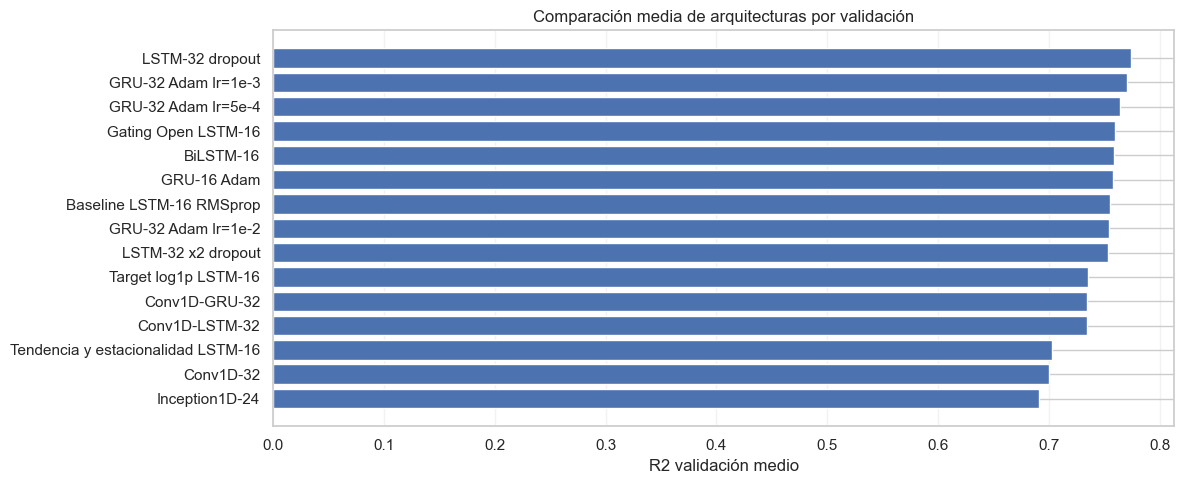

In [23]:
plt.figure(figsize=(12, 5))
plot_df = tabla_arquitecturas.sort_values("R2_val_medio", ascending=True)
plt.barh(plot_df["modelo"], plot_df["R2_val_medio"])
plt.xlabel("R2 validación medio")
plt.title("Comparación media de arquitecturas por validación")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### Curvas de entrenamiento de los modelos ganadores

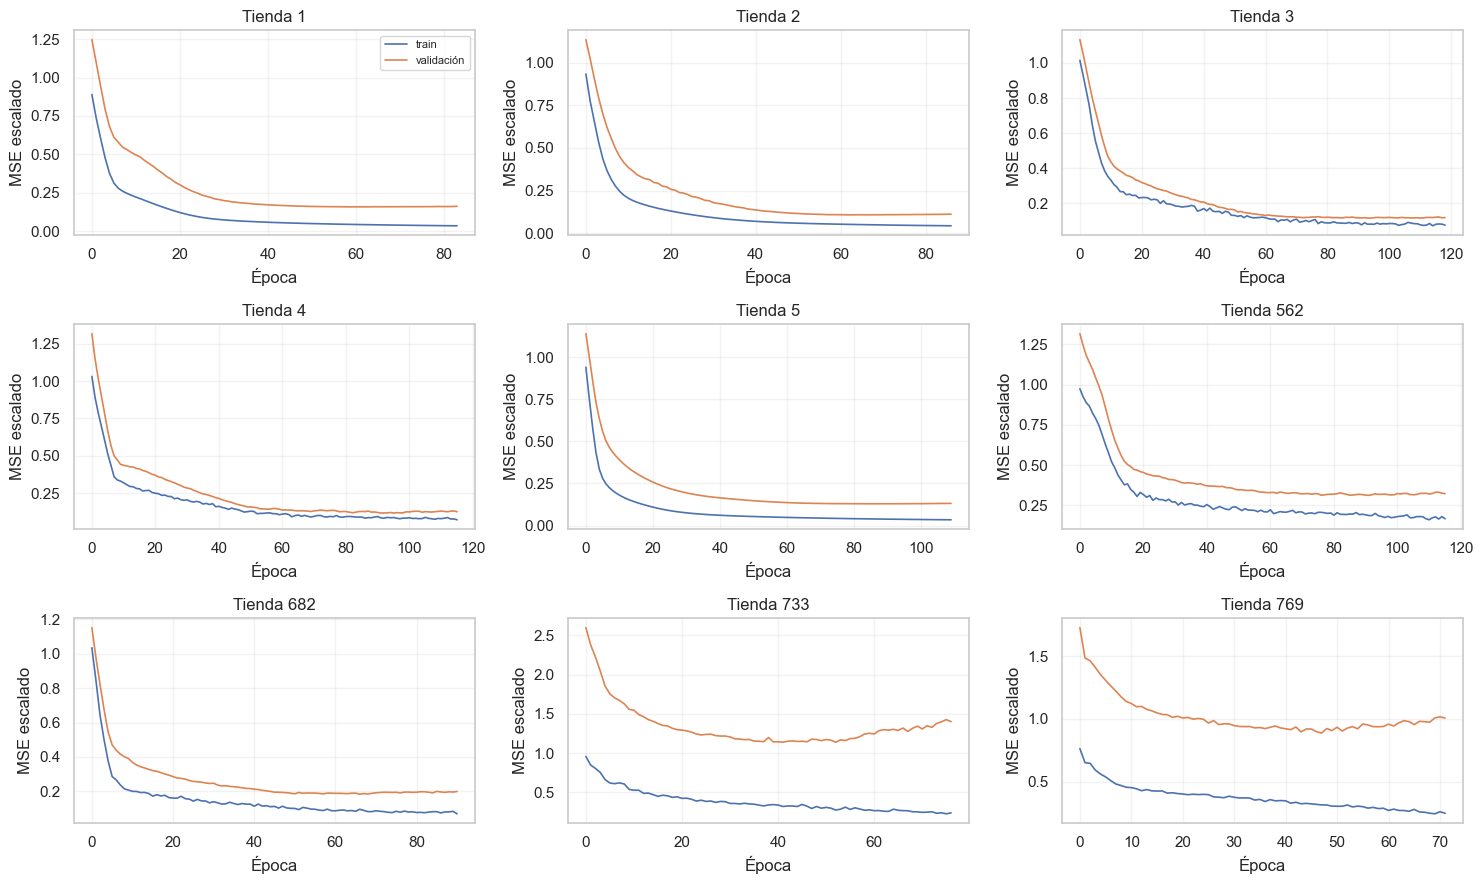

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, tienda in zip(axes, TIENDAS):
    history = historias_ganadoras[tienda].history
    ax.plot(history["loss"], label="train", linewidth=1.2)
    ax.plot(history["val_loss"], label="validación", linewidth=1.2)
    ax.set_title(f"Tienda {tienda}")
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE escalado")
    ax.grid(True, alpha=0.25)

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### R² por tienda

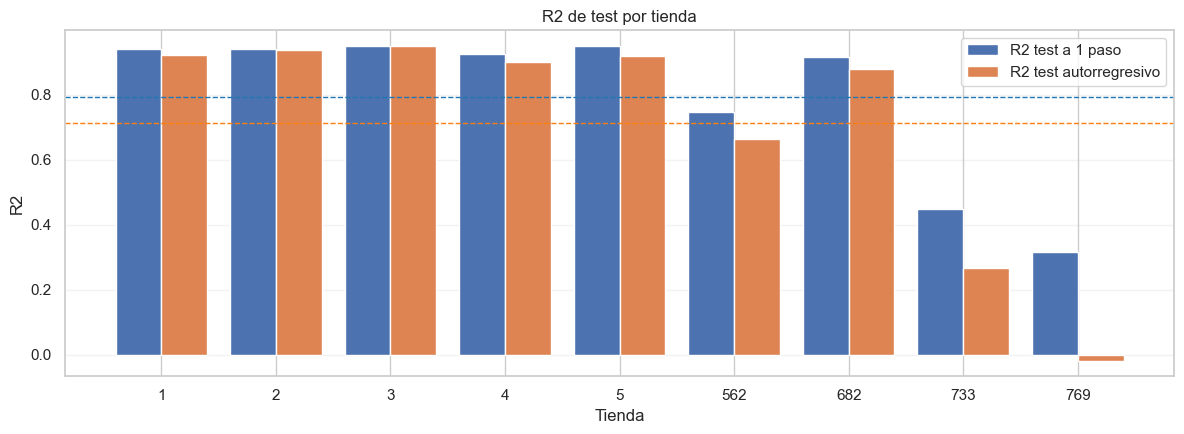

In [25]:
x = np.arange(len(tabla_final))
plt.figure(figsize=(12, 4.5))
plt.bar(x - 0.2, tabla_final["R2_test_1_paso"], width=0.4, label="R2 test a 1 paso")
plt.bar(x + 0.2, tabla_final["R2_test_autorregresivo"], width=0.4, label="R2 test autorregresivo")
plt.axhline(tabla_final["R2_test_1_paso"].mean(), color="tab:blue", linestyle="--", linewidth=1)
plt.axhline(tabla_final["R2_test_autorregresivo"].mean(), color="tab:orange", linestyle="--", linewidth=1)
plt.xticks(x, tabla_final["tienda"].astype(str))
plt.xlabel("Tienda")
plt.ylabel("R2")
plt.title("R2 de test por tienda")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## <font color="#CA3532"> **12. Predicción autorregresiva: real vs predicho**</font>

En esta sección se comparan, por tienda, las ventas reales del test con la trayectoria generada por el modelo ganador.


### **Evaluación autorregresiva**

La predicción autorregresiva representa un escenario más estricto: para avanzar por el test, el modelo no puede usar ventas reales futuras como rezagos, sino que debe reutilizar sus propias predicciones. Esto penaliza los errores acumulados y permite comprobar si el modelo es estable al predecir varios días consecutivos.

Por este motivo se presentan dos lecturas complementarias. El R² a un paso mide la capacidad del modelo cuando los rezagos reales están disponibles. El R² autorregresivo mide la robustez cuando el modelo debe generar la trayectoria completa de test de forma secuencial.


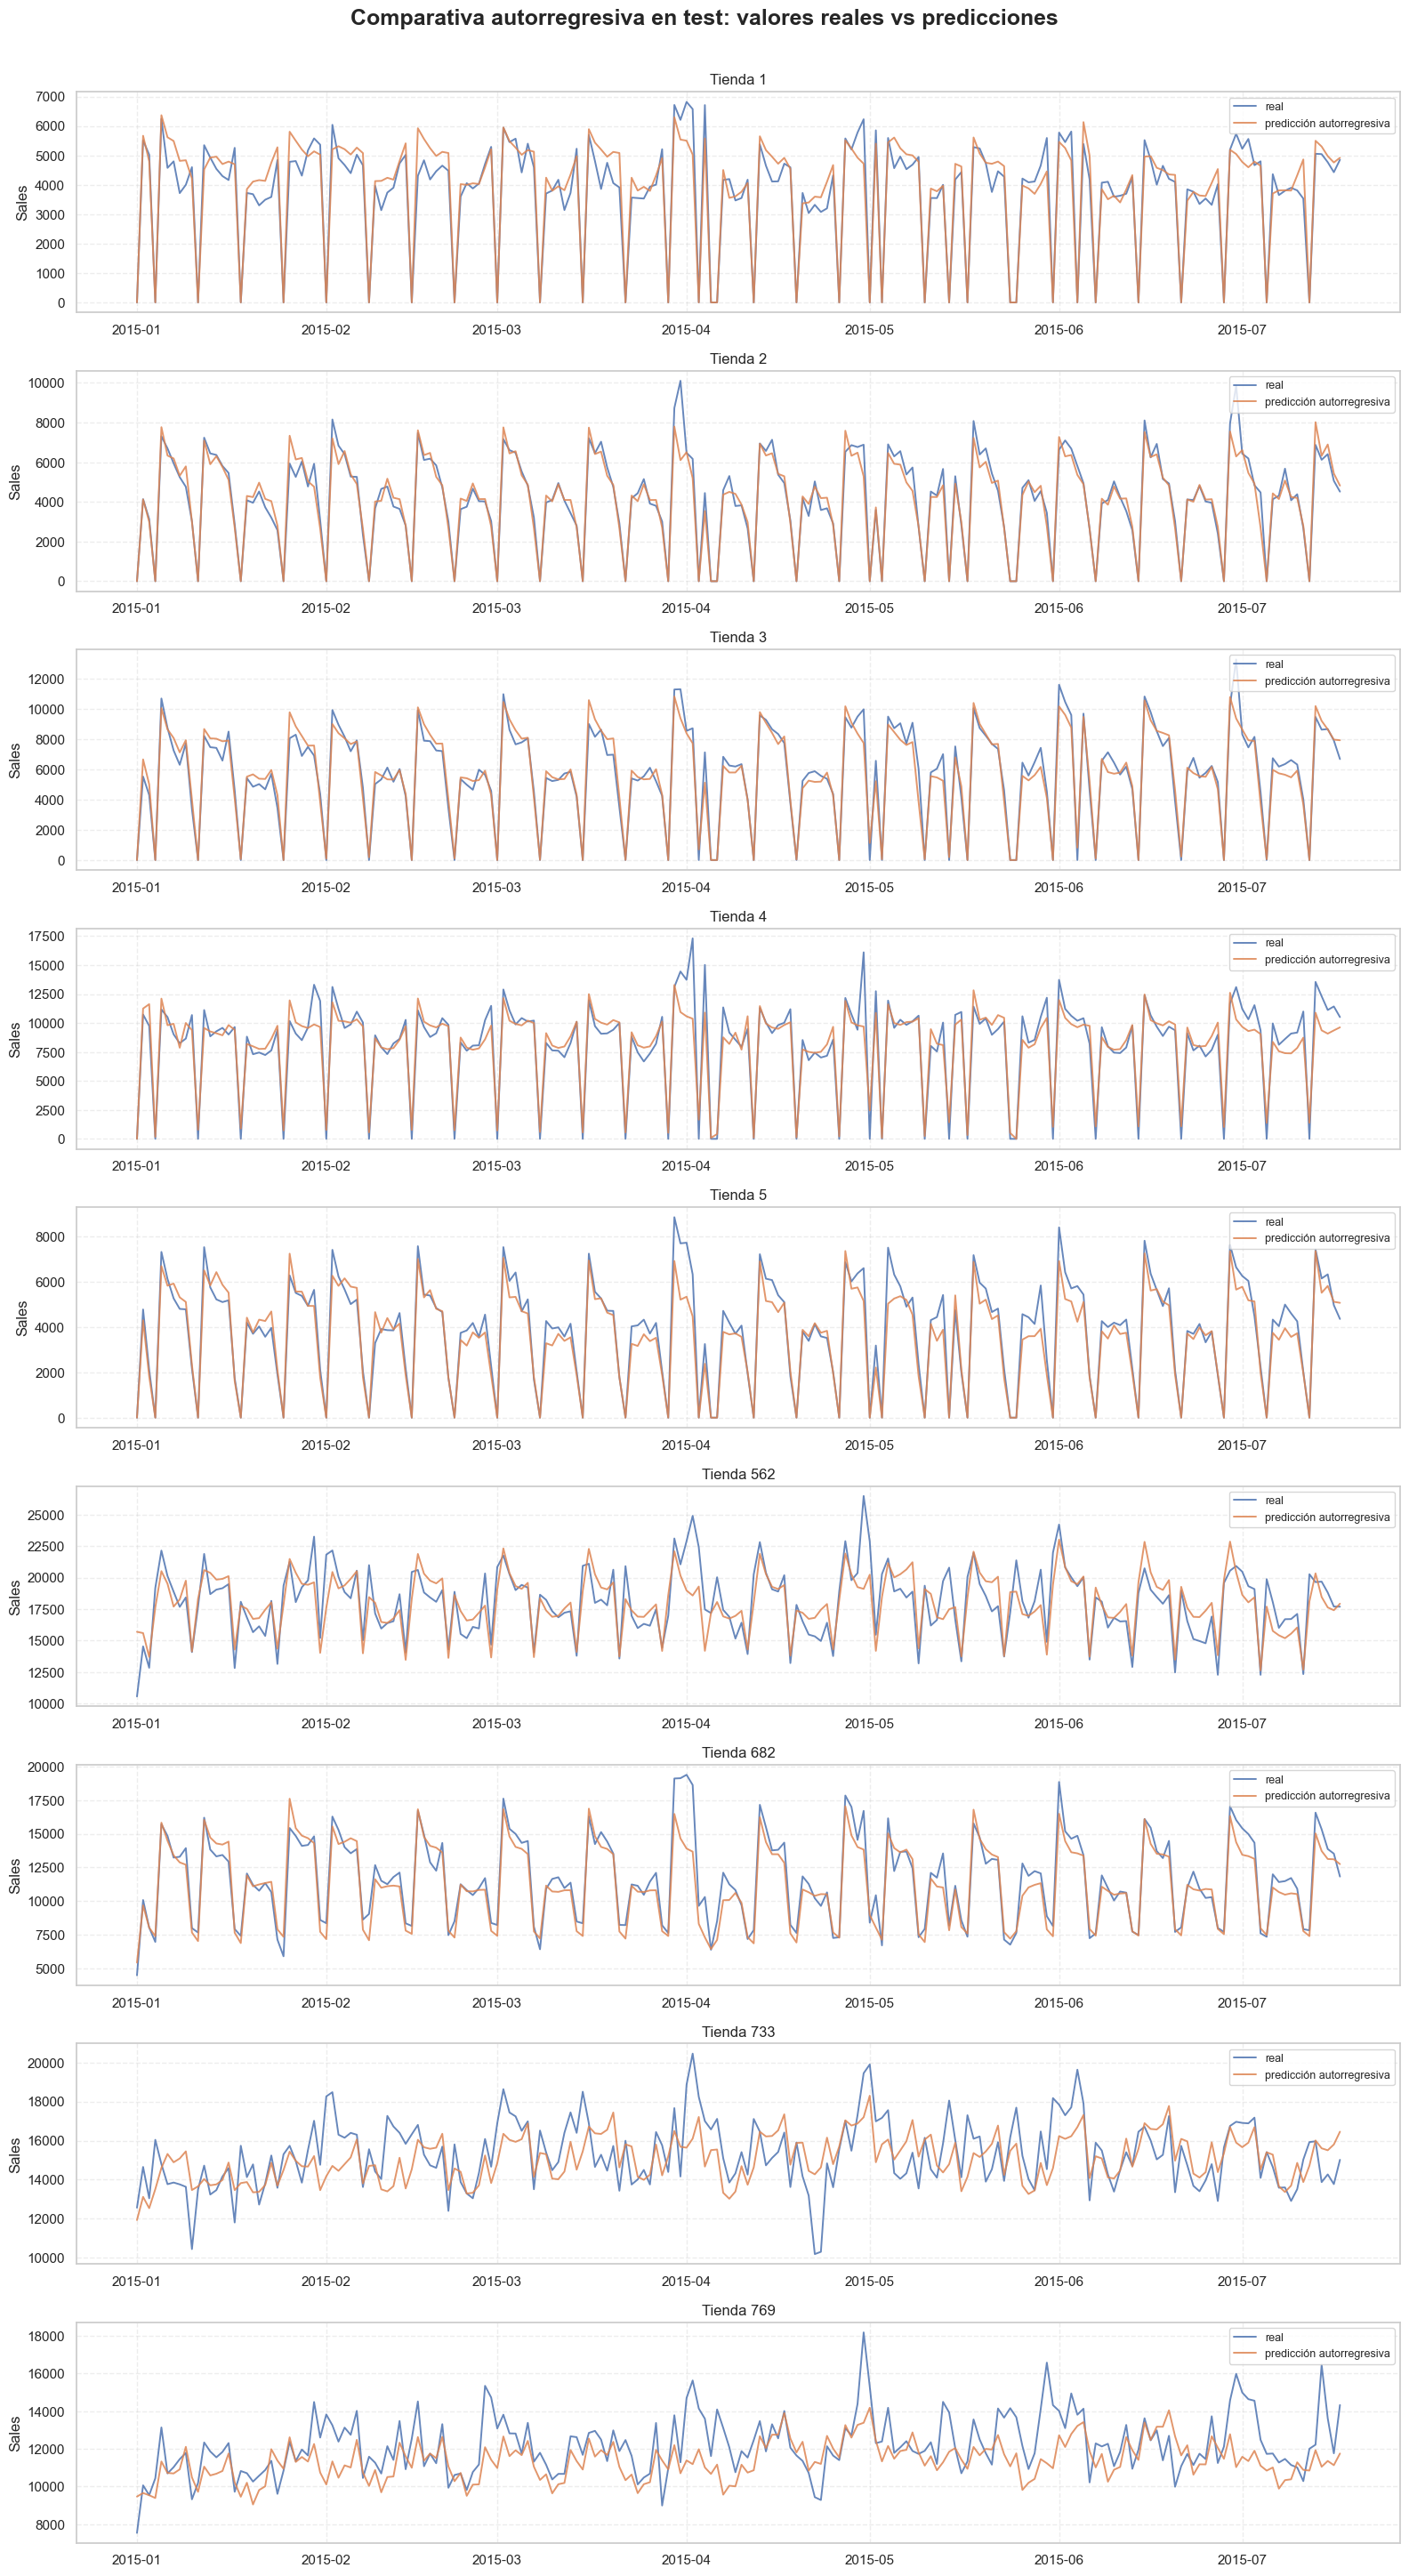

In [26]:
fig, axes = plt.subplots(nrows=len(TIENDAS), ncols=1, figsize=(16, 3.2 * len(TIENDAS)), sharex=False)
fig.suptitle("Comparativa autorregresiva en test: valores reales vs predicciones", fontsize=18, fontweight="bold", y=1.005)

for ax, tienda in zip(axes, TIENDAS):
    fechas = datos_tiendas[tienda]["fechas"]["te"]
    reales = datos_tiendas[tienda]["reales"]["te"]
    pred = predicciones_ganadoras[tienda]["pred_test_autorregresivo"]

    ax.plot(fechas, reales, label="real", linewidth=1.4, alpha=0.85)
    ax.plot(fechas, pred, label="predicción autorregresiva", linewidth=1.4, alpha=0.85)
    ax.set_title(f"Tienda {tienda}")
    ax.set_ylabel("Sales")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

## <font color="#CA3532"> **13. Guardado de resultados**</font>

In [27]:
tabla_final.to_csv(RESULTADOS_DIR / "resultados_r2_tiendas.csv", index=False)
tabla_arquitecturas.to_csv(RESULTADOS_DIR / "comparacion_arquitecturas.csv", index=False)
resultados_modelos.to_csv(RESULTADOS_DIR / "resultados_todos_los_modelos.csv", index=False)
resumen_global.to_csv(RESULTADOS_DIR / "resumen_global.csv", index=False)

try:
    tabla_final.to_excel(RESULTADOS_DIR / "resultados_r2_tiendas.xlsx", index=False)
    tabla_arquitecturas.to_excel(RESULTADOS_DIR / "comparacion_arquitecturas.xlsx", index=False)
    resultados_modelos.to_excel(RESULTADOS_DIR / "resultados_todos_los_modelos.xlsx", index=False)
    resumen_global.to_excel(RESULTADOS_DIR / "resumen_global.xlsx", index=False)
    print("Resultados guardados en CSV y Excel")
except ImportError:
    print("Resultados guardados en CSV. Para Excel hace falta openpyxl.")

Resultados guardados en CSV y Excel


## <font color="#CA3532"> **14. Conclusiones y reflexión crítica**</font>

La práctica se resuelve con modelos neuronales de entradas heterogéneas y con entrenamiento individualizado por tienda. La estrategia es coherente con el problema porque las tiendas presentan escalas de venta, cierres, promociones y patrones temporales diferentes. Además, el uso de Keras Functional API permite tratar cada tipo de variable de forma adecuada antes de unirlas en una representación común.

La solución combina tres grupos de entradas:

- variables categóricas con embeddings (`DayOfWeek`, `StateHoliday`, `Month`);
- variables binarias conocidas antes de la predicción (`Open`, `Promo`, `SchoolHoliday`);
- variables históricas basadas en ventas pasadas (`Sales_lag_1_day`, `Sales_lag_2_day`, `Sales_lag_1_week`, `Sales_lag_2_week`).

El procedimiento seguido evita fuga de información: `Customers` no se utiliza, los datos se dividen respetando el tiempo y los escaladores se ajustan solo con entrenamiento. La selección de modelos se realiza con validación temporal, no con test, lo que hace que la comparación sea más honesta.

Los resultados muestran una mejora clara frente a los modelos de referencia. La evaluación a un paso ofrece los valores más altos, mientras que la evaluación autorregresiva reduce el rendimiento por la acumulación de errores. Las tiendas 733 y 769 son las más difíciles, lo que sugiere patrones menos regulares o mayor sensibilidad a factores no incluidos en las variables disponibles.

Como limitaciones principales:

- la lista de tiendas disponible contiene 9 identificadores;
- el periodo de test llega hasta julio de 2015 y no cubre un año completo;
- la ventana temporal es corta (`DATA_WINDOW = 5`) y puede no capturar patrones más largos;
- la búsqueda de hiperparámetros es razonable para el alcance de la práctica, pero no exhaustiva;
- la evaluación autorregresiva es sensible a la acumulación de error, especialmente en tiendas con menor regularidad.

Como mejoras futuras se podrían probar ventanas más largas, más semillas, búsqueda bayesiana o aleatoria de hiperparámetros, modelos globales con embedding de tienda y variables adicionales externas si estuvieran disponibles. Aun así, la solución presentada es sólida para los objetivos de la práctica: compara modelos de referencia y arquitecturas, justifica la preparación de datos, respeta la estructura temporal y ofrece una reflexión crítica de los resultados.
